In [1]:
import pandas as pd
import numpy as np
import talib
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import bt
import optuna
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


from statsmodels.tsa.stattools import acf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

/opt/anaconda3/envs/stock_trading/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [2]:
# Load BCA data
tickers = ["BBCA.JK"]
bbca = yf.Ticker("BBCA.JK")
data = bbca.history(start="2020-01-01")
data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2020-01-02 00:00:00+07:00,5787.021605,5860.493873,5774.055911,5782.699707,49445000,0.0,0.0
2020-01-03 00:00:00+07:00,5834.563240,5877.782227,5812.953746,5877.782227,47755500,0.0,0.0
2020-01-06 00:00:00+07:00,5808.631473,5834.562863,5782.700082,5821.597168,27300000,0.0,0.0
2020-01-07 00:00:00+07:00,5821.596559,5851.849845,5817.274661,5825.918457,45022500,0.0,0.0
2020-01-08 00:00:00+07:00,5765.411868,5830.240337,5765.411868,5774.055664,53692500,0.0,0.0
...,...,...,...,...,...,...,...
2026-03-11 00:00:00+07:00,6975.000000,7000.000000,6825.000000,6825.000000,91723400,0.0,0.0
2026-03-12 00:00:00+07:00,6825.000000,7025.000000,6825.000000,6900.000000,98787400,0.0,0.0
2026-03-13 00:00:00+07:00,6850.000000,7025.000000,6850.000000,6875.000000,107940600,0.0,0.0


In [3]:
# Split data into training and testing sets
train_data = data.iloc[:int(0.8 * len(data))]
test_data = data.iloc[int(0.8 * len(data)):]

# Return Distribution Analysis

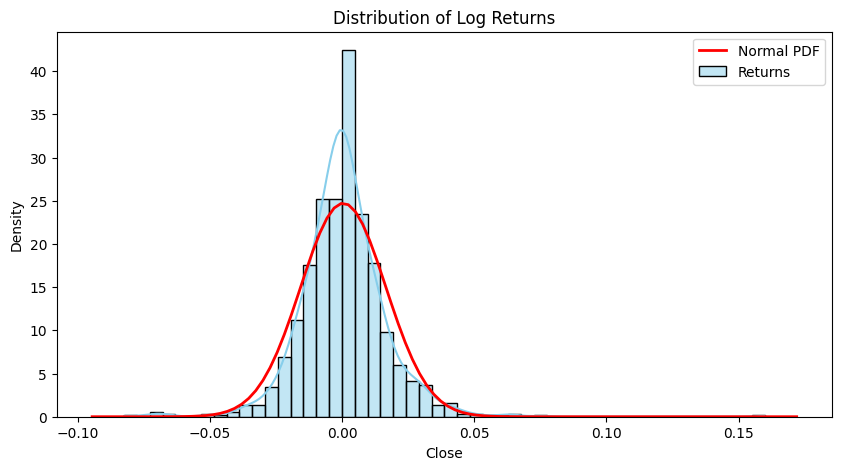

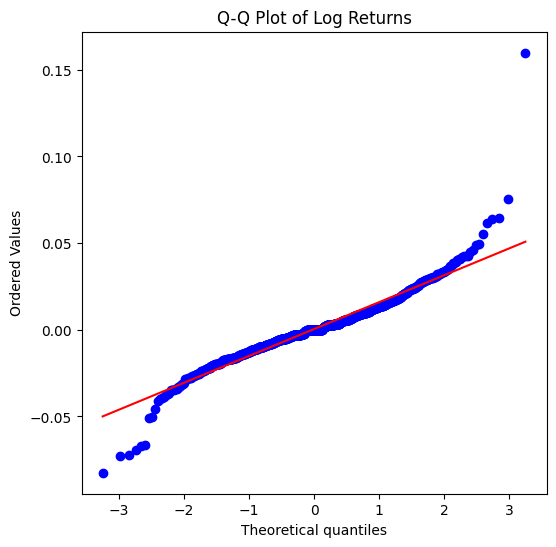

Shapiro-Wilk test:      statistic=0.9240, p-value=4.2281e-24
Kolmogorov-Smirnov:     statistic=0.0739, p-value=4.0195e-06
Jarque-Bera test:       statistic=5457.7294, p-value=0.0000e+00

The log returns are NOT normally distributed (fat tails present).
Excess kurtosis: 10.3610 (Normal = 0; >0 indicates fat tails)


In [4]:
# --- Fat-tail test: Check if returns are normally distributed ---
# Compute log returns
log_returns = np.log(train_data['Close']).diff().dropna()

# Histogram with normal curve overlay
plt.figure(figsize=(10, 5))
sns.histplot(log_returns, bins=50, kde=True, stat="density", color='skyblue', label='Returns')
# Fit a normal curve
mu, std = log_returns.mean(), log_returns.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, stats.norm.pdf(x, mu, std), 'r-', lw=2, label='Normal PDF')
plt.title("Distribution of Log Returns")
plt.legend()
plt.show()

# Q-Q Plot to visually check normality
plt.figure(figsize=(6, 6))
stats.probplot(log_returns, dist="norm", plot=plt)
plt.title("Q-Q Plot of Log Returns")
plt.show()

# Formal normality tests
shapiro_stat, shapiro_p = stats.shapiro(log_returns)
ks_stat, ks_p = stats.kstest(log_returns, 'norm', args=(mu, std))
jb_stat, jb_p = stats.jarque_bera(log_returns)

print(f"Shapiro-Wilk test:      statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
print(f"Kolmogorov-Smirnov:     statistic={ks_stat:.4f}, p-value={ks_p:.4e}")
print(f"Jarque-Bera test:       statistic={jb_stat:.4f}, p-value={jb_p:.4e}")

if shapiro_p < 0.05 or ks_p < 0.05 or jb_p < 0.05:
    print("\nThe log returns are NOT normally distributed (fat tails present).")
else:
    print("\nThe log returns are consistent with normality.")

# Additionally, check excess kurtosis (should be ~0 for normal, >0 for fat tails)
excess_kurtosis = stats.kurtosis(log_returns, fisher=True)
print(f"Excess kurtosis: {excess_kurtosis:.4f} (Normal = 0; >0 indicates fat tails)")

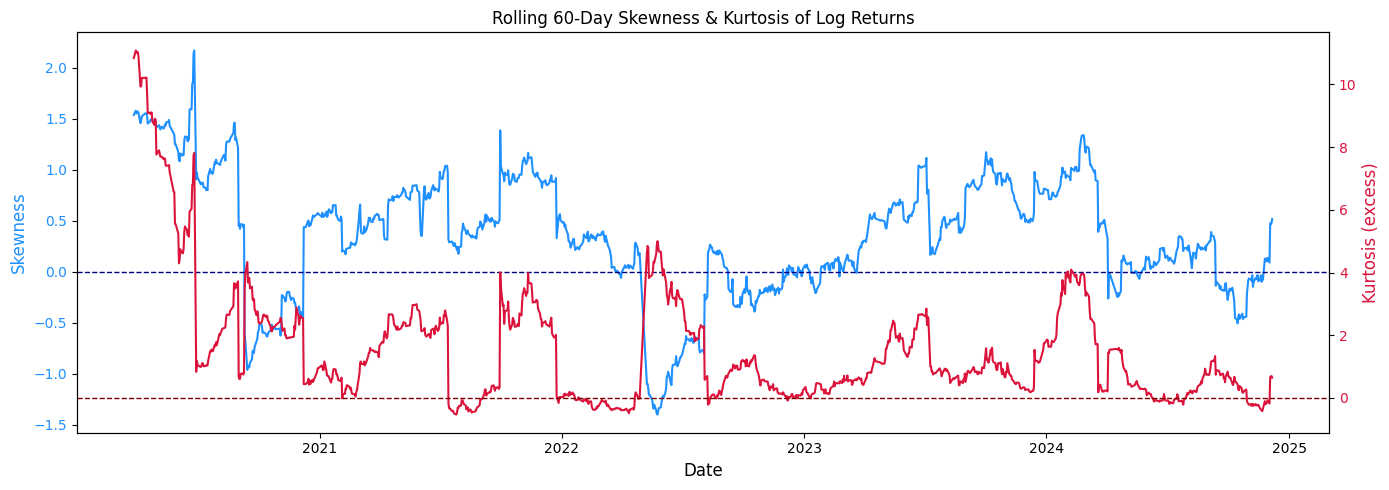

Mean rolling skewness: 0.3515
Mean rolling excess kurtosis: 1.5154

--- Interpretation ---
• Skewness (0.3515): Returns are RIGHT-SKEWED on average — more frequent small losses but occasional large gains (favorable for investors).
• Kurtosis (1.5154): Returns exhibit FAT TAILS (leptokurtic) — extreme moves occur more often than a normal distribution predicts. Standard risk models may underestimate tail risk.


In [5]:
# --- Rolling Skewness and Kurtosis Analysis ---

window = 60  # e.g., 60 days = ~3 months; adjust as needed

rolling_skew = log_returns.rolling(window).skew()
rolling_kurtosis = log_returns.rolling(window).kurt()

fig, ax1 = plt.subplots(figsize=(14,5))

ax1.plot(rolling_skew, color='dodgerblue', label='Rolling Skewness')
ax1.axhline(0, color='navy', ls='--', lw=1)
ax1.set_ylabel("Skewness", color='dodgerblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='dodgerblue')
ax1.set_xlabel("Date", fontsize=12)

ax2 = ax1.twinx()
ax2.plot(rolling_kurtosis, color='crimson', label='Rolling Kurtosis')
ax2.axhline(0, color='maroon', ls='--', lw=1)
ax2.set_ylabel("Kurtosis (excess)", color='crimson', fontsize=12)
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title(f"Rolling {window}-Day Skewness & Kurtosis of Log Returns")
fig.tight_layout()
plt.show()

# Summary statistics
mean_skew = rolling_skew.mean()
mean_kurt = rolling_kurtosis.mean()

print(f"Mean rolling skewness: {mean_skew:.4f}")
print(f"Mean rolling excess kurtosis: {mean_kurt:.4f}")

# Summary interpretation
print("\n--- Interpretation ---")
if mean_skew > 0.1:
    print(f"• Skewness ({mean_skew:.4f}): Returns are RIGHT-SKEWED on average — more frequent small losses but occasional large gains (favorable for investors).")
elif mean_skew < -0.1:
    print(f"• Skewness ({mean_skew:.4f}): Returns are LEFT-SKEWED on average — more frequent small gains but risk of large losses (unfavorable tail risk).")
else:
    print(f"• Skewness ({mean_skew:.4f}): Returns are approximately SYMMETRIC — no strong directional bias in tail behavior.")

if mean_kurt > 1:
    print(f"• Kurtosis ({mean_kurt:.4f}): Returns exhibit FAT TAILS (leptokurtic) — extreme moves occur more often than a normal distribution predicts. Standard risk models may underestimate tail risk.")
elif mean_kurt < -0.5:
    print(f"• Kurtosis ({mean_kurt:.4f}): Returns are THIN-TAILED (platykurtic) — fewer extreme moves than expected. Market behavior is relatively orderly.")
else:
    print(f"• Kurtosis ({mean_kurt:.4f}): Returns have NEAR-NORMAL tails — standard deviation is a reasonable risk proxy during typical periods.")

# Volatility Structure (GARCH)

In [6]:
# ARCH-LM Test for Conditional Heteroskedasticity

from statsmodels.stats.diagnostic import het_arch

# We'll use the log returns calculated above
arch_test_lags = 12  # typical lag to start with

arch_lm_result = het_arch(log_returns, nlags=arch_test_lags)

print("ARCH-LM Test Results (lags={}):".format(arch_test_lags))
print(f"LM Stat: {arch_lm_result[0]:.4f} | p-value: {arch_lm_result[1]:.4g}")
print("F-test Stat: {:.4f} | F-test p-value: {:.4g}".format(arch_lm_result[2], arch_lm_result[3]))

# Interpretation
if arch_lm_result[1] < 0.05:
    print("Significant ARCH effect detected (conditional volatility is present). GARCH modeling is appropriate.")
else:
    print("No significant ARCH effect detected (conditional volatility not strongly present).")

ARCH-LM Test Results (lags=12):
LM Stat: 111.0900 | p-value: 3.642e-18
F-test Stat: 10.1039 | F-test p-value: 4.123e-19
Significant ARCH effect detected (conditional volatility is present). GARCH modeling is appropriate.


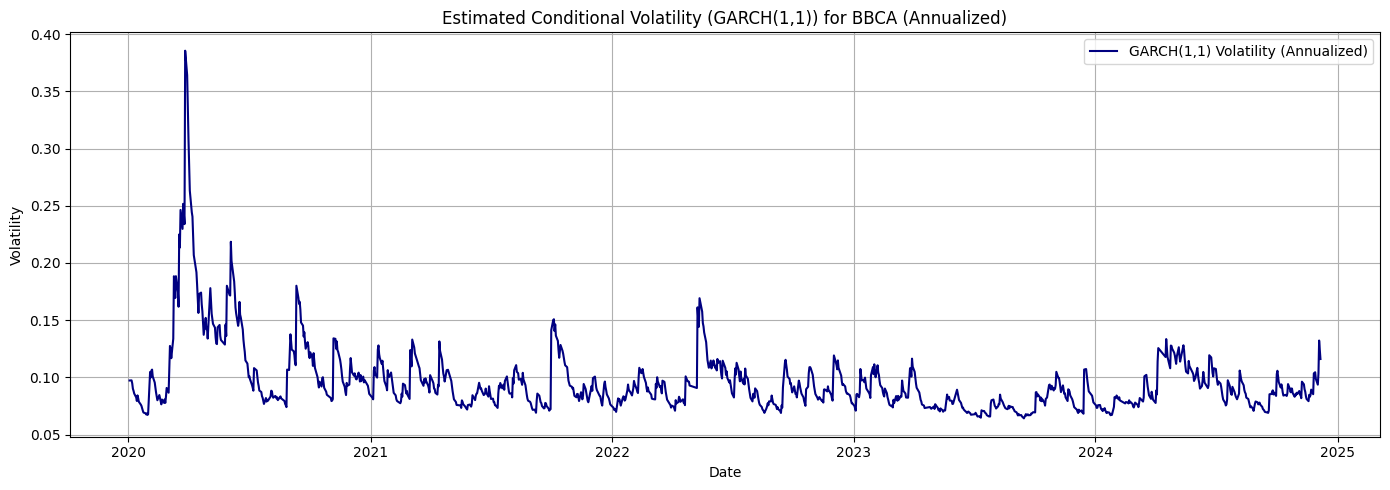

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                  Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2158.73
Distribution:                  Normal   AIC:                           4325.45
Method:            Maximum Likelihood   BIC:                           4345.80
                                        No. Observations:                 1196
Date:                Mon, Mar 23 2026   Df Residuals:                     1195
Time:                        08:17:49   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0887  3.956e-02      2.241  2.503e-02 [1.112e-0

In [7]:
# --- Visualize Volatility Structure (GARCH) ---

from arch import arch_model

# Fit GARCH(1,1) model to log returns
garch_model = arch_model(log_returns * 100, vol='Garch', p=1, q=1, mean='Constant', rescale=False)
garch_res = garch_model.fit(disp='off')

# Extract conditional volatility (annualized)
cond_vol = garch_res.conditional_volatility / np.sqrt(252)  # daily sigma, annualized

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(log_returns.index, cond_vol, color='navy', label='GARCH(1,1) Volatility (Annualized)')
ax.set_title('Estimated Conditional Volatility (GARCH(1,1)) for BBCA (Annualized)')
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# Print GARCH parameters summary
print(garch_res.summary())

# --- GARCH Model Interpretation Summary ---
print("\n" + "="*60)
print("GARCH(1,1) MODEL INTERPRETATION SUMMARY")
print("="*60)

# Extract key parameters
omega = garch_res.params['omega']
alpha = garch_res.params['alpha[1]']
beta = garch_res.params['beta[1]']
persistence = alpha + beta

print(f"\nKey Parameters:")
print(f"  ω (omega)  = {omega:.6f}  (baseline variance)")
print(f"  α (alpha)  = {alpha:.4f}  (shock impact coefficient)")
print(f"  β (beta)   = {beta:.4f}  (volatility persistence coefficient)")
print(f"  α + β      = {persistence:.4f}  (volatility persistence)")

print(f"\nInterpretation:")
if persistence >= 0.99:
    print("  → Extremely high persistence: volatility shocks decay very slowly (near unit root)")
elif persistence >= 0.95:
    print("  → High persistence: volatility clusters strongly; shocks take a long time to dissipate")
elif persistence >= 0.85:
    print("  → Moderate persistence: volatility mean-reverts at a reasonable pace")
else:
    print("  → Low persistence: volatility shocks dissipate quickly")

if alpha > 0.1:
    print("  → High α: market is reactive to recent shocks (news impact is significant)")
else:
    print("  → Moderate/low α: market absorbs shocks without dramatic volatility spikes")

if beta > 0.8:
    print("  → High β: past volatility strongly predicts future volatility")

# Half-life of volatility shocks
if persistence < 1:
    half_life = np.log(0.5) / np.log(persistence)
    print(f"\n  Volatility shock half-life: ~{half_life:.1f} trading days")

print("\nPractical Implications:")
print("  - GARCH effects confirm volatility clustering in BBCA returns")
print("  - Risk models should account for time-varying volatility")
print("  - VaR/CVaR estimates should use conditional (not unconditional) volatility")
print("="*60)

# Seasonality & Calendar Effects

/var/folders/89/vrmgb1613rdfq24nyt6b9hfw0000gp/T/ipykernel_85346/2760930515.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([day_labels[d] for d in dow_grouped.groups.keys()])


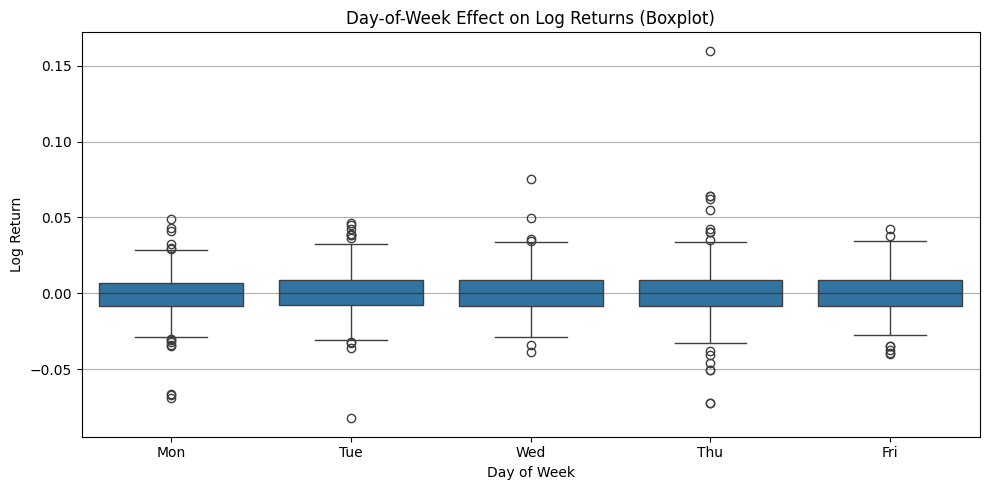

Mean log return by day of week:
Mon: -0.00082
Tue: 0.00082
Wed: 0.00075
Thu: 0.00145
Fri: -0.00002


In [8]:
# --- Day-of-Week Return Distribution Analysis ---

# Compute log returns if not already available
if 'log_returns' not in locals():
    log_returns = np.log(train_data['Close']).diff().dropna()

# Add day-of-week column (0=Monday, ..., 6=Sunday)
dow_returns = log_returns.copy()
dow_returns = pd.DataFrame(dow_returns)
dow_returns.columns = ['Log Return']
dow_returns['DayOfWeek'] = dow_returns.index.dayofweek

# Group returns by day of week
dow_grouped = dow_returns.groupby('DayOfWeek')['Log Return']

# Prepare labels (Monday=0, ..., Friday=4)
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Boxplot of returns by day of week
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='DayOfWeek', y='Log Return', data=dow_returns, ax=ax)
ax.set_xticklabels([day_labels[d] for d in dow_grouped.groups.keys()])
ax.set_title('Day-of-Week Effect on Log Returns (Boxplot)')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Log Return')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Print mean return by day of week
print("Mean log return by day of week:")
for d in range(5):  # 0-4 = Mon-Fri, skip weekends (stock market closed)
    mean_ret = dow_grouped.mean().get(d, np.nan)
    print(f"{day_labels[d]}: {mean_ret:.5f}")

/var/folders/89/vrmgb1613rdfq24nyt6b9hfw0000gp/T/ipykernel_81049/1193945457.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_labels)


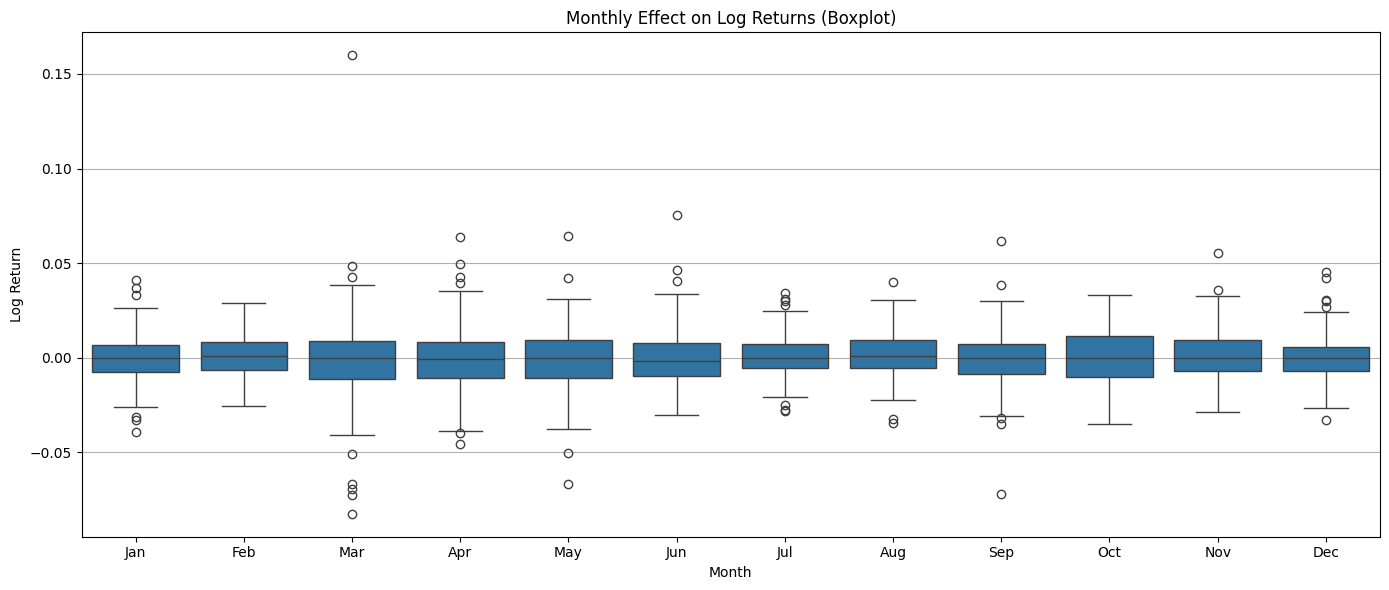

Mean log return by calendar month:
Jan: 0.00016
Feb: 0.00087
Mar: -0.00133
Apr: 0.00021
May: -0.00122
Jun: 0.00052
Jul: 0.00119
Aug: 0.00210
Sep: -0.00073
Oct: 0.00138
Nov: 0.00099
Dec: 0.00083


In [14]:
# --- Monthly Return Seasonality Analysis ---

# Compute log returns if not already available
if 'log_returns' not in locals():
    log_returns = np.log(train_data['Close']).diff().dropna()

# Add month column (1=Jan, ..., 12=Dec)
month_returns = log_returns.copy()
month_returns = pd.DataFrame(month_returns)
month_returns.columns = ['Log Return']
month_returns['Month'] = month_returns.index.month

# Group returns by month
month_grouped = month_returns.groupby('Month')['Log Return']

# Prepare labels for months
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Boxplot of returns by month
fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(x='Month', y='Log Return', data=month_returns, ax=ax)
ax.set_xticklabels(month_labels)
ax.set_title('Monthly Effect on Log Returns (Boxplot)')
ax.set_xlabel('Month')
ax.set_ylabel('Log Return')
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Print mean return by month
print("Mean log return by calendar month:")
for m in range(1, 13):  # 1-12 = Jan-Dec
    mean_ret = month_grouped.mean().get(m, np.nan)
    print(f"{month_labels[m-1]}: {mean_ret:.5f}")

Using 20 estimated earnings dates for analysis


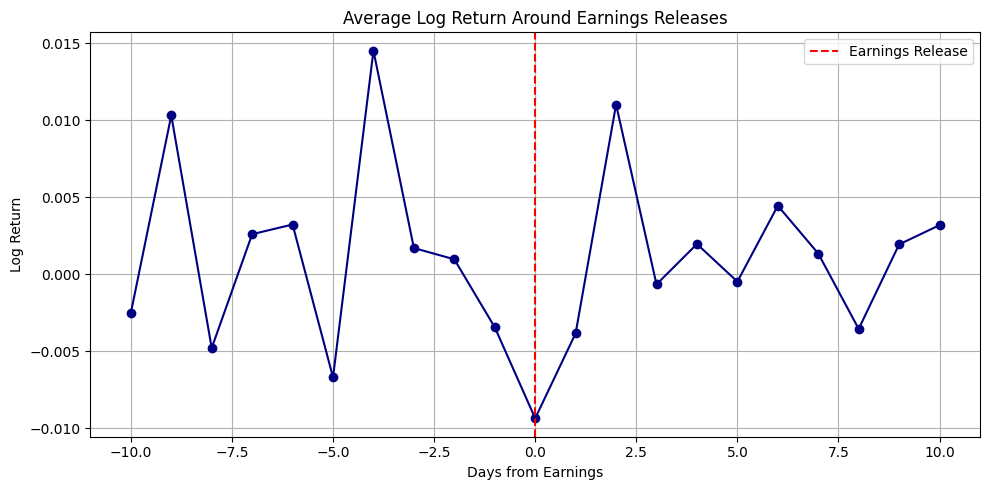

Mean log returns around earnings (day 0 = earnings day):
-10: -0.00252
-9: 0.01031
-8: -0.00479
-7: 0.00260
-6: 0.00323
-5: -0.00669
-4: 0.01451
-3: 0.00170
-2: 0.00097
-1: -0.00345
+0: -0.00936
+1: -0.00384
+2: 0.01102
+3: -0.00066
+4: 0.00196
+5: -0.00048
+6: 0.00444
+7: 0.00134
+8: -0.00355
+9: 0.00194
+10: 0.00318

INTERPRETATION: Pre/Post Earnings Behavior

📊 Pre-Earnings Period (days -5 to -1):
   • Average daily return: 0.00141 (0.141%)
   • Cumulative return: 0.00703 (0.703%)
   ➡️  Evidence of PRE-EARNINGS DRIFT: Stock tends to rise before announcements

📅 Earnings Day (day 0):
   • Average return: -0.00936 (-0.936%)
   ➡️  Moderate reaction on earnings day

📈 Post-Earnings Period (days +1 to +5):
   • Average daily return: 0.00160 (0.160%)
   • Cumulative return: 0.00800 (0.800%)
   ➡️  Evidence of POST-EARNINGS ANNOUNCEMENT DRIFT (PEAD)

💡 Trading Implications:
   • Consider entering long positions ~5 days before expected earnings
   • Momentum continuation after positive ea

In [9]:
# --- Pre/Post Earnings Behavior Analysis ---
import numpy as np

bbca_calendar = bbca.calendar
earnings_dates = []

# Helper to normalize any timestamp to tz-naive UTC
def to_utc_naive(dt):
    dt = pd.to_datetime(dt)
    if dt.tzinfo is not None:
        dt = dt.tz_convert('UTC').tz_localize(None)
    return dt

# Extract earnings dates from the calendar
if 'Earnings Date' in bbca_calendar and bbca_calendar['Earnings Date']:
    for ed in bbca_calendar['Earnings Date']:
        earnings_dates.append(to_utc_naive(ed))

# Normalize train_data index to tz-naive UTC as well
if train_data.index.tzinfo is not None:
    train_data.index = train_data.index.tz_convert('UTC').tz_localize(None)

train_index_min = train_data.index.min()

# Estimate past quarterly earnings
if earnings_dates:
    latest_earnings = earnings_dates[0]
    for i in range(1, 20):
        past_date = to_utc_naive(latest_earnings - pd.DateOffset(months=3*i))
        if past_date >= train_index_min:
            earnings_dates.append(past_date)

# Now safe to convert — all are tz-naive
earnings_dates = pd.to_datetime(earnings_dates)
print(f"Using {len(earnings_dates)} estimated earnings dates for analysis")

N_DAYS = 10
returns_around_earnings = []

for event_date in earnings_dates:
    event_date = to_utc_naive(event_date)  # ensure consistent

    try:
        closest_idx = train_data.index.get_indexer([event_date], method='nearest')[0]
        if closest_idx < 0:
            continue
        idx = closest_idx
    except (KeyError, IndexError):
        continue

    expected_len = 2 * N_DAYS + 1
    padded_window = np.full(expected_len, np.nan)

    data_start = max(0, idx - N_DAYS)
    data_end   = min(len(log_returns), idx + N_DAYS + 1)
    padded_start = data_start - (idx - N_DAYS)

    window = log_returns.iloc[data_start:data_end].values
    if len(window) > 0:
        padded_window[padded_start:padded_start + len(window)] = window

    returns_around_earnings.append(padded_window)

if returns_around_earnings:
    returns_matrix = np.array(returns_around_earnings)
    mean_returns = np.nanmean(returns_matrix, axis=0)
    std_returns = np.nanstd(returns_matrix, axis=0)
    days = np.arange(-N_DAYS, N_DAYS + 1)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(days, mean_returns, marker='o', color='navy')
    ax.axvline(0, color='red', linestyle='--', label='Earnings Release')
    ax.set_title('Average Log Return Around Earnings Releases')
    ax.set_xlabel('Days from Earnings')
    ax.set_ylabel('Log Return')
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Mean log returns around earnings (day 0 = earnings day):")
    for d, ret in zip(days, mean_returns):
        print(f"{d:+}: {ret:.5f}")
    
    # --- Interpretation of Earnings Analysis ---
    print("\n" + "="*60)
    print("INTERPRETATION: Pre/Post Earnings Behavior")
    print("="*60)
    
    # Calculate pre-earnings drift (days -5 to -1)
    pre_earnings_mask = (days >= -5) & (days < 0)
    pre_earnings_avg = np.nanmean(mean_returns[pre_earnings_mask])
    
    # Calculate post-earnings drift (days +1 to +5)
    post_earnings_mask = (days > 0) & (days <= 5)
    post_earnings_avg = np.nanmean(mean_returns[post_earnings_mask])
    
    # Earnings day return
    earnings_day_return = mean_returns[days == 0][0]
    
    # Cumulative returns
    pre_cumulative = np.nansum(mean_returns[pre_earnings_mask])
    post_cumulative = np.nansum(mean_returns[post_earnings_mask])
    
    print(f"\n📊 Pre-Earnings Period (days -5 to -1):")
    print(f"   • Average daily return: {pre_earnings_avg:.5f} ({pre_earnings_avg*100:.3f}%)")
    print(f"   • Cumulative return: {pre_cumulative:.5f} ({pre_cumulative*100:.3f}%)")
    if pre_earnings_avg > 0.001:
        print(f"   ➡️  Evidence of PRE-EARNINGS DRIFT: Stock tends to rise before announcements")
    elif pre_earnings_avg < -0.001:
        print(f"   ➡️  Unusual pre-earnings selling pressure detected")
    else:
        print(f"   ➡️  No significant pre-earnings drift detected")
    
    print(f"\n📅 Earnings Day (day 0):")
    print(f"   • Average return: {earnings_day_return:.5f} ({earnings_day_return*100:.3f}%)")
    if abs(earnings_day_return) > 0.01:
        print(f"   ➡️  HIGH VOLATILITY on earnings day (|return| > 1%)")
    else:
        print(f"   ➡️  Moderate reaction on earnings day")
    
    print(f"\n📈 Post-Earnings Period (days +1 to +5):")
    print(f"   • Average daily return: {post_earnings_avg:.5f} ({post_earnings_avg*100:.3f}%)")
    print(f"   • Cumulative return: {post_cumulative:.5f} ({post_cumulative*100:.3f}%)")
    if post_earnings_avg > 0.001:
        print(f"   ➡️  Evidence of POST-EARNINGS ANNOUNCEMENT DRIFT (PEAD)")
    elif post_earnings_avg < -0.001:
        print(f"   ➡️  Post-earnings reversal or negative drift")
    else:
        print(f"   ➡️  No significant post-earnings drift detected")
    
    print(f"\n💡 Trading Implications:")
    if pre_earnings_avg > 0.001:
        print(f"   • Consider entering long positions ~5 days before expected earnings")
    if abs(earnings_day_return) > 0.01:
        print(f"   • Earnings day shows high volatility - options strategies may be valuable")
    if post_earnings_avg > 0.001:
        print(f"   • Momentum continuation after positive earnings may be tradeable")
    elif post_earnings_avg < -0.001:
        print(f"   • Consider taking profits before/on earnings day")
    
    print("\n⚠️  Note: This analysis uses estimated quarterly earnings dates.")
    print("   Actual earnings dates should be verified for trading decisions.")
    
else:
    print("No earnings date overlaps available in the dataset for pre/post earnings analysis.")

# Structural Break Detection

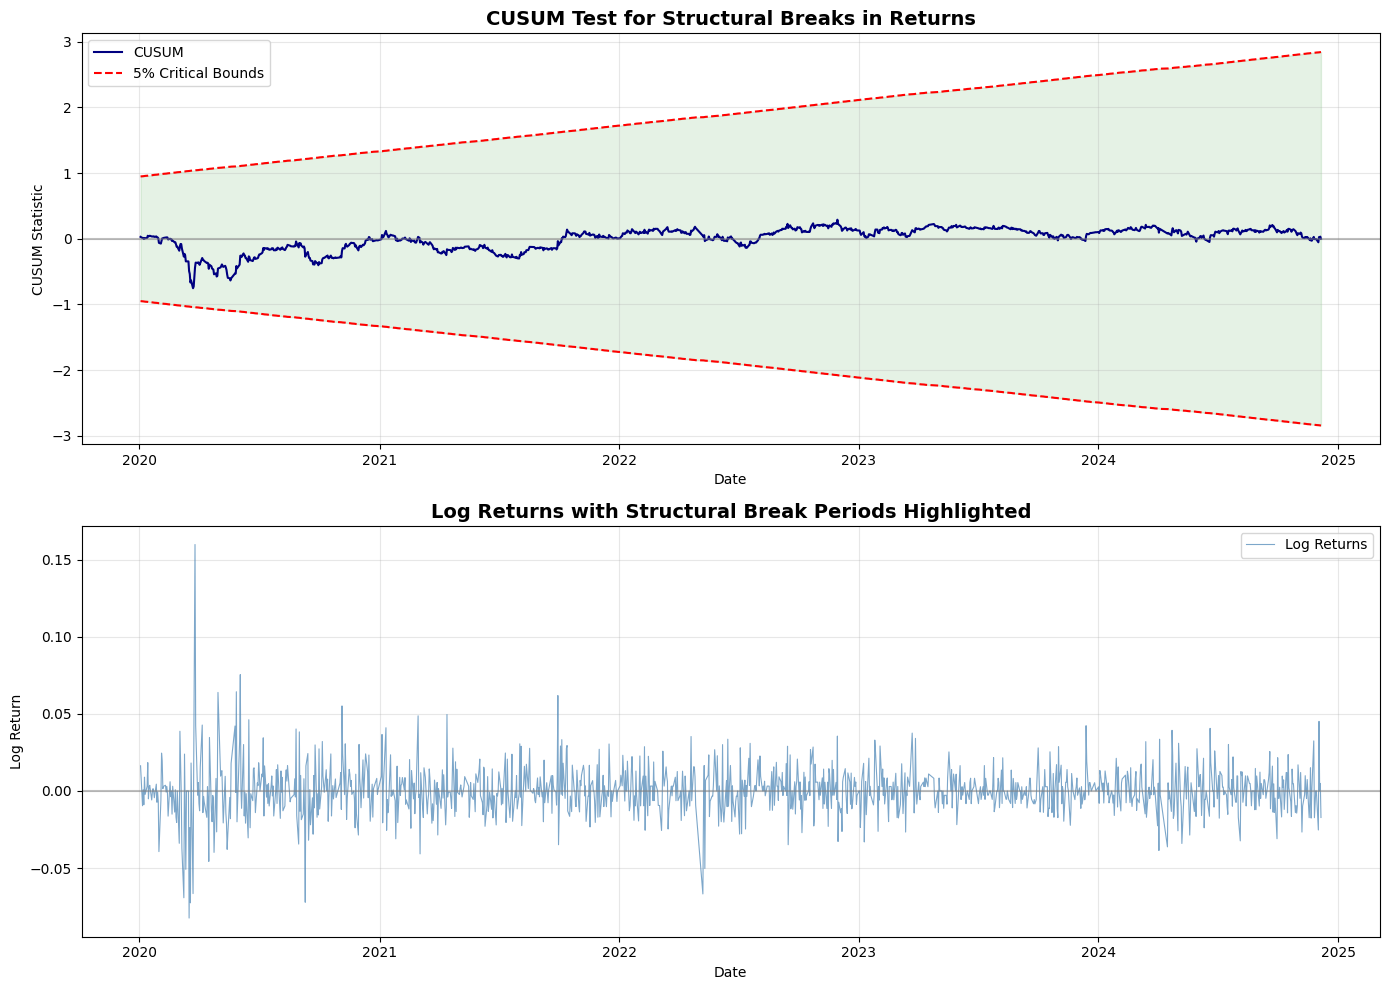

CUSUM TEST FOR STRUCTURAL BREAKS

Max |CUSUM| statistic: 0.7530
5% Critical boundary:  2.8440

Null Hypothesis: No structural break in the mean of returns
Result: FAIL TO REJECT H0 - No significant structural break

No periods exceeded the critical bounds.

INTERPRETATION
• The return-generating process appears stable over the sample period
• Historical parameters may be used for forecasting with more confidence
• Single-regime models are likely appropriate


In [24]:
# --- CUSUM Test for Structural Break Detection ---
# The CUSUM (Cumulative Sum) test detects changes in the mean of a time series
# A significant deviation from the expected cumulative sum indicates a structural break

from statsmodels.stats.diagnostic import breaks_cusumolsresid
import statsmodels.api as sm

# Compute log returns
log_returns_struct = np.log(train_data['Close']).diff().dropna()

# For CUSUM test, we regress returns on a constant (testing for mean shift)
X = sm.add_constant(np.arange(len(log_returns_struct)))
y = log_returns_struct.values

# Fit OLS model
model = sm.OLS(y, X).fit()
residuals = model.resid

# Compute CUSUM statistics
n = len(residuals)
sigma = np.std(residuals, ddof=1)
cusum = np.cumsum(residuals) / (sigma * np.sqrt(n))

# Critical values for 5% significance level (Brown-Durbin-Evans bounds)
# The boundaries are ±0.948 at the endpoints, with linear interpolation
t = np.arange(1, n + 1) / n
upper_bound = 0.948 * (1 + 2 * t)
lower_bound = -0.948 * (1 + 2 * t)

# Alternative: Standard boundaries (±a * sqrt(n) where a ≈ 1.36 for 5%)
k = np.arange(1, n + 1)
boundary_5pct = 1.36 * np.sqrt(n) + 2 * 1.36 * k / np.sqrt(n)
boundary_5pct_lower = -boundary_5pct

# Simplified boundary (commonly used)
simple_upper = 0.948 + 2 * 0.948 * t
simple_lower = -0.948 - 2 * 0.948 * t

# Detect breaks: where CUSUM exceeds boundaries
breaks_detected = np.where((cusum > simple_upper) | (cusum < simple_lower))[0]

# Plot CUSUM
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: CUSUM with boundaries
ax1 = axes[0]
ax1.plot(log_returns_struct.index, cusum, color='navy', linewidth=1.5, label='CUSUM')
ax1.plot(log_returns_struct.index, simple_upper, 'r--', linewidth=1.5, label='5% Critical Bounds')
ax1.plot(log_returns_struct.index, simple_lower, 'r--', linewidth=1.5)
ax1.fill_between(log_returns_struct.index, simple_lower, simple_upper, alpha=0.1, color='green')
ax1.axhline(0, color='gray', linestyle='-', alpha=0.5)

if len(breaks_detected) > 0:
    first_break_idx = breaks_detected[0]
    ax1.axvline(log_returns_struct.index[first_break_idx], color='orange', linestyle='--', 
                linewidth=2, label=f'First Break: {log_returns_struct.index[first_break_idx].strftime("%Y-%m-%d")}')

ax1.set_title('CUSUM Test for Structural Breaks in Returns', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('CUSUM Statistic')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Log returns with detected break periods highlighted
ax2 = axes[1]
ax2.plot(log_returns_struct.index, log_returns_struct.values, color='steelblue', 
         linewidth=0.8, alpha=0.7, label='Log Returns')

# Highlight periods where CUSUM exceeds bounds
if len(breaks_detected) > 0:
    # Find contiguous break regions
    break_starts = [breaks_detected[0]]
    break_ends = []
    for i in range(1, len(breaks_detected)):
        if breaks_detected[i] - breaks_detected[i-1] > 1:
            break_ends.append(breaks_detected[i-1])
            break_starts.append(breaks_detected[i])
    break_ends.append(breaks_detected[-1])
    
    for start, end in zip(break_starts, break_ends):
        ax2.axvspan(log_returns_struct.index[start], log_returns_struct.index[end], 
                   alpha=0.3, color='red', label='Structural Break Period' if start == break_starts[0] else '')

ax2.axhline(0, color='gray', linestyle='-', alpha=0.5)
ax2.set_title('Log Returns with Structural Break Periods Highlighted', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Statistical Summary ---
max_cusum = np.max(np.abs(cusum))
max_boundary = np.max(simple_upper)
break_detected = max_cusum > max_boundary

print("=" * 60)
print("CUSUM TEST FOR STRUCTURAL BREAKS")
print("=" * 60)
print(f"\nMax |CUSUM| statistic: {max_cusum:.4f}")
print(f"5% Critical boundary:  {max_boundary:.4f}")
print(f"\nNull Hypothesis: No structural break in the mean of returns")
print(f"Result: {'REJECT H0 - Structural break detected!' if break_detected else 'FAIL TO REJECT H0 - No significant structural break'}")

if len(breaks_detected) > 0:
    print(f"\nNumber of periods exceeding bounds: {len(breaks_detected)}")
    print(f"First break date: {log_returns_struct.index[breaks_detected[0]].strftime('%Y-%m-%d')}")
    print(f"Last break date:  {log_returns_struct.index[breaks_detected[-1]].strftime('%Y-%m-%d')}")
else:
    print("\nNo periods exceeded the critical bounds.")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
if break_detected:
    print("• The return-generating process shows evidence of structural change")
    print("• Model parameters estimated on historical data may not be stable")
    print("• Consider using adaptive/rolling estimation windows")
    print("• Regime-switching models may be appropriate")
else:
    print("• The return-generating process appears stable over the sample period")
    print("• Historical parameters may be used for forecasting with more confidence")
    print("• Single-regime models are likely appropriate")

# External Correlation

BBCA returns: 1196 rows, index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
IHSG returns: 1195 rows, index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
USD/IDR returns: 1286 rows, index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Combined (outer join): 1527 rows, NaN counts: {'BBCA': 331, 'IHSG': 332, 'USD/IDR': 241}
Aligned data: 917 trading days
Date range: 2020-01-06 to 2024-12-05

CORRELATION MATRIX (Log Returns)
           BBCA    IHSG  USD/IDR
BBCA     1.0000  0.0157   0.0206
IHSG     0.0157  1.0000  -0.0359
USD/IDR  0.0206 -0.0359   1.0000


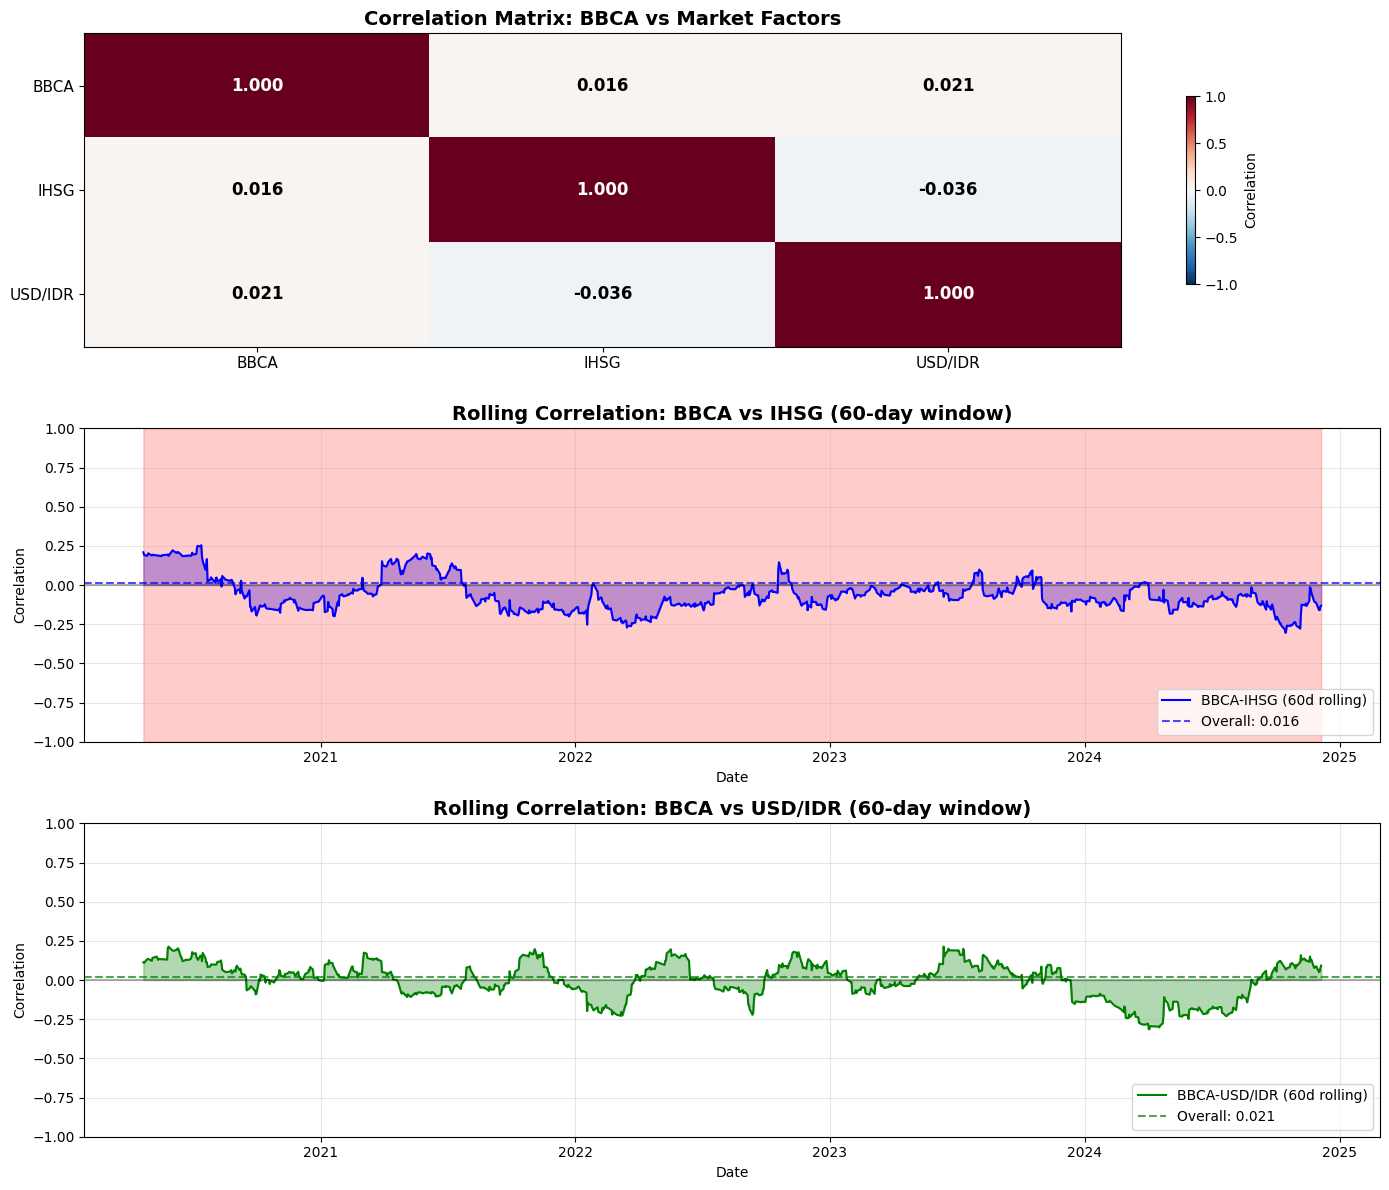


DECOUPLING ANALYSIS DURING MARKET STRESS

Number of crash days identified: 17
Number of normal days: 885

BBCA-IHSG Correlation during crashes: 0.2327
BBCA-IHSG Correlation during normal periods: -0.0452
Difference: 0.2779

→ BBCA shows INCREASED correlation during crashes
  This suggests higher systematic risk during market stress

CORRELATION SUMMARY

Static Correlations (full period):
  BBCA vs IHSG:    0.0157
  BBCA vs USD/IDR: 0.0206

Rolling Correlation Statistics (BBCA-IHSG):
  Mean:   -0.0624
  Std:    0.1073
  Min:    -0.3052
  Max:    0.2543

Rolling Correlation Statistics (BBCA-USD/IDR):
  Mean:   -0.0002
  Std:    0.1133
  Min:    -0.3149
  Max:    0.2135

INTERPRETATION
• BBCA shows low correlation with IHSG - significant idiosyncratic risk
• BBCA shows minimal currency sensitivity


In [36]:
# --- External Correlation Analysis ---
# Analyze BBCA's correlation with key market factors: IHSG (market index) and USD/IDR (currency)

import yfinance as yf

# Download external data for the same period as training data
start_date = train_data.index.min()
end_date = train_data.index.max()

# IHSG (Jakarta Composite Index) - ^JKSE
# USD/IDR exchange rate - USDIDR=X
print("Downloading external market data...")
ihsg = yf.download("^JKSE", start=start_date, end=end_date, progress=False)
usdidr = yf.download("USDIDR=X", start=start_date, end=end_date, progress=False)

# Check if data was downloaded successfully
if ihsg.empty:
    print("WARNING: IHSG data download failed. Check ticker symbol or connection.")
if usdidr.empty:
    print("WARNING: USD/IDR data download failed. Check ticker symbol or connection.")

# Calculate log returns for all series
bbca_returns = np.log(train_data['Close']).diff().dropna()

# Handle MultiIndex columns from yfinance (newer versions return MultiIndex)
if isinstance(ihsg.columns, pd.MultiIndex):
    ihsg_close = ihsg['Close'].iloc[:, 0] if ihsg['Close'].ndim > 1 else ihsg['Close']
else:
    ihsg_close = ihsg['Close']

if isinstance(usdidr.columns, pd.MultiIndex):
    usdidr_close = usdidr['Close'].iloc[:, 0] if usdidr['Close'].ndim > 1 else usdidr['Close']
else:
    usdidr_close = usdidr['Close']

# Ensure the series are 1D and have proper index
ihsg_close = pd.Series(ihsg_close.values.flatten(), index=ihsg_close.index) if len(ihsg_close) > 0 else pd.Series(dtype=float)
usdidr_close = pd.Series(usdidr_close.values.flatten(), index=usdidr_close.index) if len(usdidr_close) > 0 else pd.Series(dtype=float)

ihsg_returns = np.log(ihsg_close).diff().dropna() if len(ihsg_close) > 0 else pd.Series(dtype=float)
usdidr_returns = np.log(usdidr_close).diff().dropna() if len(usdidr_close) > 0 else pd.Series(dtype=float)

# Rename series for clarity
bbca_returns.name = 'BBCA'
ihsg_returns.name = 'IHSG'
usdidr_returns.name = 'USD/IDR'

# Ensure bbca_returns is a 1D Series
if isinstance(bbca_returns, pd.DataFrame):
    bbca_returns = bbca_returns.iloc[:, 0]
bbca_returns = pd.Series(bbca_returns.values.flatten(), index=bbca_returns.index, name='BBCA')

# Convert timezone-aware indices to timezone-naive for proper alignment
if bbca_returns.index.tz is not None:
    bbca_returns.index = bbca_returns.index.tz_localize(None)
if len(ihsg_returns) > 0 and ihsg_returns.index.tz is not None:
    ihsg_returns.index = ihsg_returns.index.tz_localize(None)
if len(usdidr_returns) > 0 and usdidr_returns.index.tz is not None:
    usdidr_returns.index = usdidr_returns.index.tz_localize(None)

# Align all series to common dates
# Debug: Check individual series before combining
print(f"BBCA returns: {len(bbca_returns)} rows, index type: {type(bbca_returns.index)}")
print(f"IHSG returns: {len(ihsg_returns)} rows, index type: {type(ihsg_returns.index) if len(ihsg_returns) > 0 else 'N/A'}")
print(f"USD/IDR returns: {len(usdidr_returns)} rows, index type: {type(usdidr_returns.index) if len(usdidr_returns) > 0 else 'N/A'}")

# Normalize index to date only (remove time component) for proper alignment
bbca_returns.index = pd.to_datetime(bbca_returns.index).normalize()
if len(ihsg_returns) > 0:
    ihsg_returns.index = pd.to_datetime(ihsg_returns.index).normalize()
if len(usdidr_returns) > 0:
    usdidr_returns.index = pd.to_datetime(usdidr_returns.index).normalize()

# Use outer join first to see all data, then fill or handle missing
combined_returns = pd.concat([bbca_returns, ihsg_returns, usdidr_returns], axis=1, join='outer')
combined_returns.columns = ['BBCA', 'IHSG', 'USD/IDR']

print(f"Combined (outer join): {len(combined_returns)} rows, NaN counts: {combined_returns.isna().sum().to_dict()}")

# Now drop rows with any NaN
combined_returns = combined_returns.dropna()

# Remove any remaining NaN or infinite values
combined_returns = combined_returns.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Aligned data: {len(combined_returns)} trading days")
# Handle potential NaT values in index
if len(combined_returns) > 0 and not pd.isna(combined_returns.index.min()) and not pd.isna(combined_returns.index.max()):
    print(f"Date range: {combined_returns.index.min().strftime('%Y-%m-%d')} to {combined_returns.index.max().strftime('%Y-%m-%d')}")
else:
    print(f"Date range: {combined_returns.index.min()} to {combined_returns.index.max()}")

# Check if we have enough data
if len(combined_returns) < 30:
    print("\nWARNING: Insufficient aligned data for reliable correlation analysis!")
    print("This may be due to missing external data or date alignment issues.")
    print("Proceeding with available data, but results may not be meaningful.\n")

# --- Static Correlation Matrix ---
corr_matrix = combined_returns.corr()

print("\n" + "=" * 60)
print("CORRELATION MATRIX (Log Returns)")
print("=" * 60)
print(corr_matrix.round(4))

# Check for NaN in correlation matrix
if corr_matrix.isna().any().any():
    print("\nWARNING: Correlation matrix contains NaN values!")
    print("This indicates insufficient data for some correlations.")

# --- Rolling Correlation Analysis ---
rolling_window = 60  # 60-day (approximately 3-month) rolling window

# Only compute rolling correlations if we have enough data
if len(combined_returns) > rolling_window:
    rolling_corr_ihsg = combined_returns['BBCA'].rolling(window=rolling_window).corr(combined_returns['IHSG'])
    rolling_corr_usdidr = combined_returns['BBCA'].rolling(window=rolling_window).corr(combined_returns['USD/IDR'])
else:
    print(f"\nWARNING: Not enough data for {rolling_window}-day rolling correlation. Using shorter window.")
    rolling_window = max(10, len(combined_returns) // 5)
    rolling_corr_ihsg = combined_returns['BBCA'].rolling(window=rolling_window).corr(combined_returns['IHSG'])
    rolling_corr_usdidr = combined_returns['BBCA'].rolling(window=rolling_window).corr(combined_returns['USD/IDR'])

# --- Visualization ---
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Static Correlation Heatmap
ax1 = axes[0]
# Replace NaN with 0 for visualization only
corr_display = corr_matrix.fillna(0)
im = ax1.imshow(corr_display.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax1.set_xticks(range(len(corr_display.columns)))
ax1.set_yticks(range(len(corr_display.columns)))
ax1.set_xticklabels(corr_display.columns, fontsize=11)
ax1.set_yticklabels(corr_display.columns, fontsize=11)
ax1.set_title('Correlation Matrix: BBCA vs Market Factors', fontsize=14, fontweight='bold')

# Add correlation values as text
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        text_val = f'{val:.3f}' if not pd.isna(val) else 'N/A'
        text_color = 'white' if (not pd.isna(val) and abs(val) > 0.5) else 'black'
        text = ax1.text(j, i, text_val,
                        ha='center', va='center', color=text_color,
                        fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax1, shrink=0.6, label='Correlation')

# Plot 2: Rolling Correlation with IHSG
ax2 = axes[1]
rolling_corr_ihsg_clean = rolling_corr_ihsg.dropna()
if len(rolling_corr_ihsg_clean) > 0:
    ax2.plot(rolling_corr_ihsg_clean.index, rolling_corr_ihsg_clean.values, color='blue', linewidth=1.5, label=f'BBCA-IHSG ({rolling_window}d rolling)')
    bbca_ihsg_corr = corr_matrix.loc['BBCA', 'IHSG']
    if not pd.isna(bbca_ihsg_corr):
        ax2.axhline(y=bbca_ihsg_corr, color='blue', linestyle='--', alpha=0.7, label=f'Overall: {bbca_ihsg_corr:.3f}')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax2.fill_between(rolling_corr_ihsg_clean.index, rolling_corr_ihsg_clean.values, 0, alpha=0.3, color='blue')
else:
    ax2.text(0.5, 0.5, 'Insufficient data for rolling correlation', ha='center', va='center', transform=ax2.transAxes)
ax2.set_title(f'Rolling Correlation: BBCA vs IHSG ({rolling_window}-day window)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Correlation')
ax2.set_ylim(-1, 1)
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# Highlight periods of low correlation (potential decoupling)
low_corr_threshold = 0.3
if len(rolling_corr_ihsg_clean) > 0:
    decoupling_periods = rolling_corr_ihsg < low_corr_threshold
    if decoupling_periods.any():
        ax2.fill_between(rolling_corr_ihsg.index, -1, 1, where=decoupling_periods, 
                         alpha=0.2, color='red', label='Decoupling (corr < 0.3)')

# Plot 3: Rolling Correlation with USD/IDR
ax3 = axes[2]
rolling_corr_usdidr_clean = rolling_corr_usdidr.dropna()
if len(rolling_corr_usdidr_clean) > 0:
    ax3.plot(rolling_corr_usdidr_clean.index, rolling_corr_usdidr_clean.values, color='green', linewidth=1.5, label=f'BBCA-USD/IDR ({rolling_window}d rolling)')
    bbca_usdidr_corr = corr_matrix.loc['BBCA', 'USD/IDR']
    if not pd.isna(bbca_usdidr_corr):
        ax3.axhline(y=bbca_usdidr_corr, color='green', linestyle='--', alpha=0.7, label=f'Overall: {bbca_usdidr_corr:.3f}')
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.fill_between(rolling_corr_usdidr_clean.index, rolling_corr_usdidr_clean.values, 0, alpha=0.3, color='green')
else:
    ax3.text(0.5, 0.5, 'Insufficient data for rolling correlation', ha='center', va='center', transform=ax3.transAxes)
ax3.set_title(f'Rolling Correlation: BBCA vs USD/IDR ({rolling_window}-day window)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Date')
ax3.set_ylabel('Correlation')
ax3.set_ylim(-1, 1)
ax3.legend(loc='lower right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Identify Market Crash Periods and Decoupling Analysis ---
# Define crash as periods where IHSG dropped significantly (e.g., cumulative -10% in 20 days)
if len(ihsg_returns) > 20:
    ihsg_cumret = ihsg_returns.rolling(window=20).sum()
    crash_threshold = -0.10  # -10% in 20 days
    crash_periods = ihsg_cumret < crash_threshold

    print("\n" + "=" * 60)
    print("DECOUPLING ANALYSIS DURING MARKET STRESS")
    print("=" * 60)

    # Get correlation during crash vs normal periods
    crash_dates = ihsg_cumret[crash_periods].index
    normal_dates = ihsg_cumret[~crash_periods].dropna().index

    # Filter to common dates
    crash_common = combined_returns.index.intersection(crash_dates)
    normal_common = combined_returns.index.intersection(normal_dates)

    if len(crash_common) > 10:
        crash_corr = combined_returns.loc[crash_common, ['BBCA', 'IHSG']].corr().iloc[0, 1]
        normal_corr = combined_returns.loc[normal_common, ['BBCA', 'IHSG']].corr().iloc[0, 1]
        
        print(f"\nNumber of crash days identified: {len(crash_common)}")
        print(f"Number of normal days: {len(normal_common)}")
        print(f"\nBBCA-IHSG Correlation during crashes: {crash_corr:.4f}")
        print(f"BBCA-IHSG Correlation during normal periods: {normal_corr:.4f}")
        print(f"Difference: {crash_corr - normal_corr:.4f}")
        
        if crash_corr < normal_corr - 0.1:
            print("\n→ BBCA shows DECOUPLING during market crashes (lower correlation)")
            print("  This suggests defensive characteristics - may outperform during stress")
        elif crash_corr > normal_corr + 0.1:
            print("\n→ BBCA shows INCREASED correlation during crashes")
            print("  This suggests higher systematic risk during market stress")
        else:
            print("\n→ BBCA maintains similar correlation regardless of market conditions")
            print("  No significant decoupling behavior detected")
    else:
        print("\nInsufficient crash periods detected for decoupling analysis")
else:
    print("\n" + "=" * 60)
    print("DECOUPLING ANALYSIS DURING MARKET STRESS")
    print("=" * 60)
    print("\nInsufficient IHSG data for crash analysis")

# --- Summary Statistics ---
print("\n" + "=" * 60)
print("CORRELATION SUMMARY")
print("=" * 60)

bbca_ihsg_corr = corr_matrix.loc['BBCA', 'IHSG']
bbca_usdidr_corr = corr_matrix.loc['BBCA', 'USD/IDR']

print(f"\nStatic Correlations (full period):")
print(f"  BBCA vs IHSG:    {bbca_ihsg_corr:.4f}" if not pd.isna(bbca_ihsg_corr) else "  BBCA vs IHSG:    N/A (insufficient data)")
print(f"  BBCA vs USD/IDR: {bbca_usdidr_corr:.4f}" if not pd.isna(bbca_usdidr_corr) else "  BBCA vs USD/IDR: N/A (insufficient data)")

if len(rolling_corr_ihsg.dropna()) > 0:
    print(f"\nRolling Correlation Statistics (BBCA-IHSG):")
    print(f"  Mean:   {rolling_corr_ihsg.mean():.4f}")
    print(f"  Std:    {rolling_corr_ihsg.std():.4f}")
    print(f"  Min:    {rolling_corr_ihsg.min():.4f}")
    print(f"  Max:    {rolling_corr_ihsg.max():.4f}")
else:
    print(f"\nRolling Correlation Statistics (BBCA-IHSG): N/A (insufficient data)")

if len(rolling_corr_usdidr.dropna()) > 0:
    print(f"\nRolling Correlation Statistics (BBCA-USD/IDR):")
    print(f"  Mean:   {rolling_corr_usdidr.mean():.4f}")
    print(f"  Std:    {rolling_corr_usdidr.std():.4f}")
    print(f"  Min:    {rolling_corr_usdidr.min():.4f}")
    print(f"  Max:    {rolling_corr_usdidr.max():.4f}")
else:
    print(f"\nRolling Correlation Statistics (BBCA-USD/IDR): N/A (insufficient data)")

print("\n" + "=" * 60)
print("INTERPRETATION")
print("=" * 60)
if pd.isna(bbca_ihsg_corr):
    print("• Unable to compute BBCA-IHSG correlation (check external data)")
elif bbca_ihsg_corr > 0.7:
    print("• BBCA is highly correlated with IHSG - strong market beta")
elif bbca_ihsg_corr > 0.4:
    print("• BBCA is moderately correlated with IHSG - some idiosyncratic behavior")
else:
    print("• BBCA shows low correlation with IHSG - significant idiosyncratic risk")

if pd.isna(bbca_usdidr_corr):
    print("• Unable to compute BBCA-USD/IDR correlation (check external data)")
elif bbca_usdidr_corr < -0.1:
    print("• BBCA shows negative correlation with USD/IDR (IDR weakness hurts)")
elif bbca_usdidr_corr > 0.1:
    print("• BBCA shows positive correlation with USD/IDR (benefits from IDR weakness)")
else:
    print("• BBCA shows minimal currency sensitivity")

# Strategy Selection EDA

Before choosing a trading strategy, we need to understand the **statistical properties** of the stock's returns. Different properties favor different strategies:

| Property | Test | Trend Following | Mean Reversion | Random Walk |
|---|---|---|---|---|
| Autocorrelation | ACF / Ljung-Box | Positive at short lags | Negative at short lags | ~Zero |
| Hurst Exponent | R/S Analysis | H > 0.5 | H < 0.5 | H ≈ 0.5 |
| Stationarity | ADF Test | Non-stationary prices | Stationary prices | Unit root |
| Variance Ratio | Lo-MacKinlay | VR > 1 (momentum) | VR < 1 (reversal) | VR ≈ 1 |
| Half-life | OLS on lagged spread | Long / ∞ | Short (days–weeks) | ∞ |

We'll run **all of these tests** on BBCA to build an evidence-based strategy recommendation.

## 1. Autocorrelation Analysis

Autocorrelation measures how today's return correlates with past returns:
- **Positive autocorrelation** → returns persist → **trend following** works
- **Negative autocorrelation** → returns reverse → **mean reversion** works
- **No autocorrelation** → random walk → neither works reliably

We use:
- **ACF plot** to visually inspect serial correlation at multiple lags
- **Ljung-Box test** to formally test if autocorrelations are statistically significant

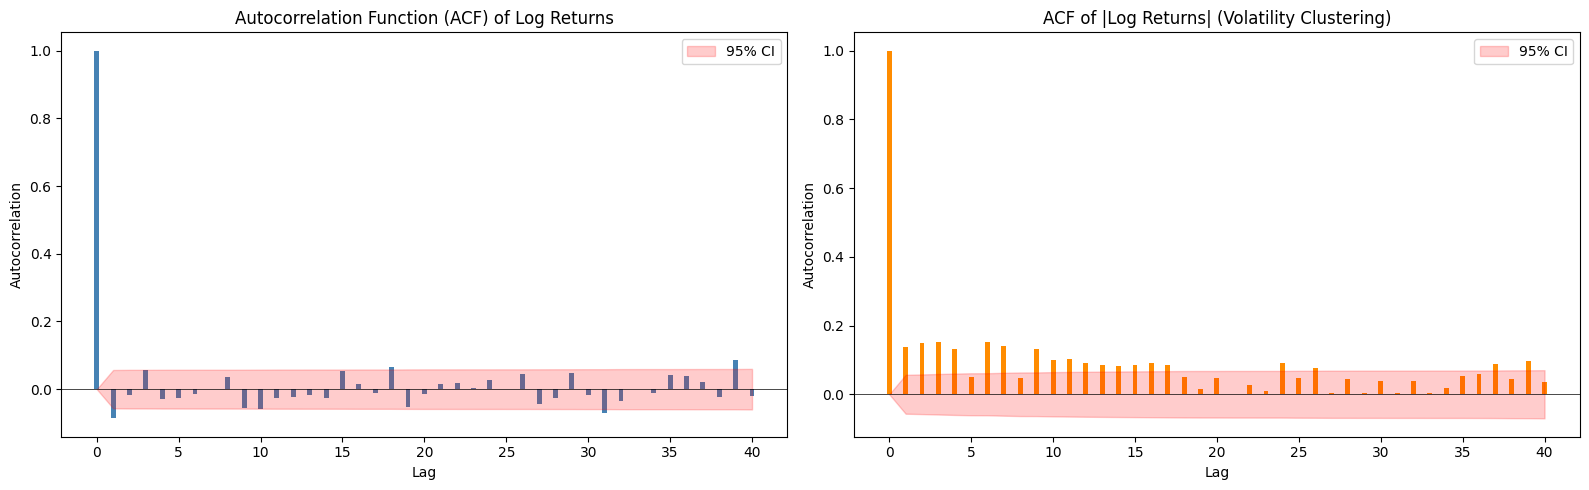

LJUNG-BOX TEST (H0: no autocorrelation up to lag k)
      lb_stat  lb_pvalue
1    8.919552   0.002821
5   14.957138   0.010547
10  24.648182   0.006054
20  39.640200   0.005545

⚠️  Significant autocorrelation detected at lags: [1, 5, 10, 20]
   → Average ACF(1-5) = -0.0202 (NEGATIVE → Mean Reversion signal)


In [4]:
# --- Compute log returns ---
log_returns = np.log(train_data['Close']).diff().dropna()

# --- ACF Plot ---
n_lags = 40
acf_values, confint = acf(log_returns, nlags=n_lags, alpha=0.05)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF bar plot
axes[0].bar(range(n_lags + 1), acf_values, color='steelblue', width=0.3)
axes[0].fill_between(range(n_lags + 1),
                      confint[:, 0] - acf_values,
                      confint[:, 1] - acf_values,
                      alpha=0.2, color='red', label='95% CI')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('Autocorrelation Function (ACF) of Log Returns')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].legend()

# ACF of absolute returns (volatility clustering)
acf_abs, confint_abs = acf(log_returns.abs(), nlags=n_lags, alpha=0.05)
axes[1].bar(range(n_lags + 1), acf_abs, color='darkorange', width=0.3)
axes[1].fill_between(range(n_lags + 1),
                      confint_abs[:, 0] - acf_abs,
                      confint_abs[:, 1] - acf_abs,
                      alpha=0.2, color='red', label='95% CI')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('ACF of |Log Returns| (Volatility Clustering)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Ljung-Box Test ---
lb_test = acorr_ljungbox(log_returns, lags=[1, 5, 10, 20], return_df=True)
print("=" * 60)
print("LJUNG-BOX TEST (H0: no autocorrelation up to lag k)")
print("=" * 60)
print(lb_test.to_string())
print()

# Interpretation
significant_lags = lb_test[lb_test['lb_pvalue'] < 0.05]
if len(significant_lags) > 0:
    print("⚠️  Significant autocorrelation detected at lags:", significant_lags.index.tolist())
    avg_acf_1_5 = np.mean(acf_values[1:6])
    if avg_acf_1_5 > 0:
        print(f"   → Average ACF(1-5) = {avg_acf_1_5:.4f} (POSITIVE → Trend Following signal)")
    else:
        print(f"   → Average ACF(1-5) = {avg_acf_1_5:.4f} (NEGATIVE → Mean Reversion signal)")
else:
    print("✅ No significant autocorrelation → Returns behave like a random walk")

There is a slight, statistically significant tendency for BBCA daily returns to partially reverse in the short term (1–5 day horizon). However, the effect size is very small (ACF ≈ -0.023) and may not be economically exploitable on its own.

## 2. Hurst Exponent (R/S Analysis)

The Hurst exponent $H$ classifies the memory of a time series:
- **H > 0.5** → Persistent (trending) → **Trend Following**
- **H = 0.5** → Random walk → No exploitable pattern
- **H < 0.5** → Anti-persistent (mean-reverting) → **Mean Reversion**

We compute it using Rescaled Range (R/S) analysis across multiple window sizes.

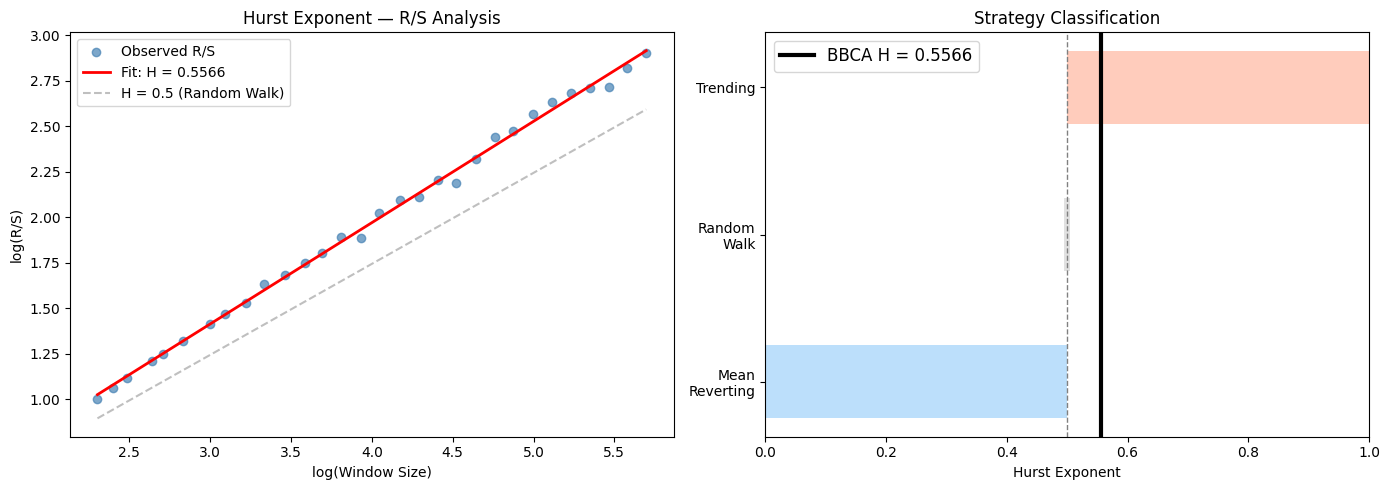

HURST EXPONENT: H = 0.5566
→ H = 0.5566 > 0.5 → PERSISTENT (Trending)
  ✅ Trend Following strategies are suitable


In [5]:
def hurst_exponent(series, min_window=10, max_window=None):
    """
    Compute the Hurst exponent using Rescaled Range (R/S) analysis.
    
    Returns: H (float), log_windows (array), log_rs (array) for plotting
    """
    series = series.dropna().values
    n = len(series)
    if max_window is None:
        max_window = n // 4
    
    window_sizes = []
    rs_values = []
    
    # Use logarithmically spaced window sizes
    for w in np.unique(np.logspace(np.log10(min_window), np.log10(max_window), 30).astype(int)):
        if w > n:
            continue
        
        rs_list = []
        n_windows = n // w
        
        for i in range(n_windows):
            window = series[i * w : (i + 1) * w]
            mean_w = np.mean(window)
            
            # Cumulative deviation from mean
            cumdev = np.cumsum(window - mean_w)
            
            # Range
            R = np.max(cumdev) - np.min(cumdev)
            
            # Standard deviation
            S = np.std(window, ddof=1)
            
            if S > 0:
                rs_list.append(R / S)
        
        if len(rs_list) > 0:
            window_sizes.append(w)
            rs_values.append(np.mean(rs_list))
    
    log_windows = np.log(window_sizes)
    log_rs = np.log(rs_values)
    
    # Fit line: log(R/S) = H * log(n) + c
    H = np.polyfit(log_windows, log_rs, 1)[0]
    
    return H, log_windows, log_rs

# Compute Hurst exponent
H, log_w, log_rs = hurst_exponent(log_returns)

# Plot R/S analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R/S plot with fitted line
fit = np.polyfit(log_w, log_rs, 1)
fit_line = np.polyval(fit, log_w)

axes[0].scatter(log_w, log_rs, color='steelblue', alpha=0.7, label='Observed R/S')
axes[0].plot(log_w, fit_line, color='red', linewidth=2, label=f'Fit: H = {H:.4f}')
axes[0].plot(log_w, 0.5 * log_w + fit[1], color='gray', linestyle='--', alpha=0.5, label='H = 0.5 (Random Walk)')
axes[0].set_xlabel('log(Window Size)')
axes[0].set_ylabel('log(R/S)')
axes[0].set_title('Hurst Exponent — R/S Analysis')
axes[0].legend()

# Hurst gauge
categories = ['Mean\nReverting', 'Random\nWalk', 'Trending']
colors = ['#2196F3', '#9E9E9E', '#FF5722']
boundaries = [0, 0.5, 0.5, 1.0]

axes[1].barh(categories, [0.5, 0.01, 0.5], left=[0, 0.495, 0.5], color=colors, alpha=0.3, height=0.5)
axes[1].axvline(H, color='black', linewidth=3, label=f'BBCA H = {H:.4f}')
axes[1].axvline(0.5, color='gray', linewidth=1, linestyle='--')
axes[1].set_xlim(0, 1)
axes[1].set_xlabel('Hurst Exponent')
axes[1].set_title('Strategy Classification')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

# Interpretation
print("=" * 60)
print(f"HURST EXPONENT: H = {H:.4f}")
print("=" * 60)
if H > 0.55:
    print(f"→ H = {H:.4f} > 0.5 → PERSISTENT (Trending)")
    print("  ✅ Trend Following strategies are suitable")
elif H < 0.45:
    print(f"→ H = {H:.4f} < 0.5 → ANTI-PERSISTENT (Mean Reverting)")
    print("  ✅ Mean Reversion strategies are suitable")
else:
    print(f"→ H = {H:.4f} ≈ 0.5 → RANDOM WALK (Weak signal)")
    print("  ⚠️  Neither strategy has a strong statistical edge")

## 3. Augmented Dickey-Fuller (ADF) Stationarity Test

The ADF test checks whether a time series has a **unit root** (non-stationary):
- **Prices non-stationary + Returns stationary** → Normal behavior, need differencing
- **Prices stationary** → Mean-reverting price → **Mean Reversion** directly on price
- **Returns non-stationary** → Unusual, may indicate structural breaks

We test both price levels and returns.

AUGMENTED DICKEY-FULLER TEST (H0: Unit root / Non-stationary)
             ADF Statistic   p-value  5% Critical  Stationary
Series                                                       
Close Price      -1.436485  0.564665    -2.863477       False
Log Returns     -19.678977  0.000000    -2.863966        True
Log Price        -1.552611  0.507344    -2.863478       False



/var/folders/89/vrmgb1613rdfq24nyt6b9hfw0000gp/T/ipykernel_31383/705647190.py:47: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/89/vrmgb1613rdfq24nyt6b9hfw0000gp/T/ipykernel_31383/705647190.py:47: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/stock_trading/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/envs/stock_trading/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


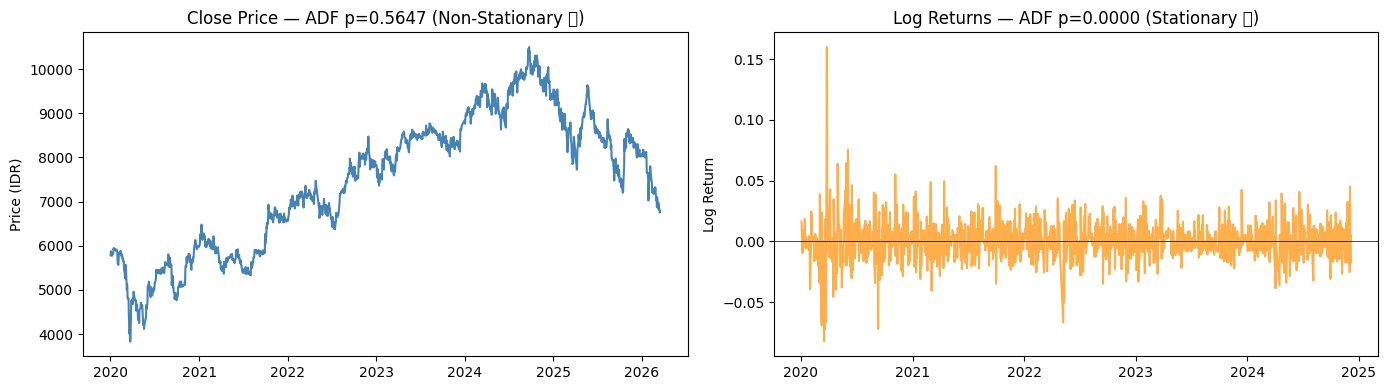

INTERPRETATION:
→ Prices are non-stationary, returns are stationary (typical behavior)
  This is consistent with a unit-root process (random walk with drift)
  → Mean reversion on RAW PRICE is NOT supported
  → Must use returns or spreads for mean reversion strategies


In [6]:
def run_adf_test(series, name="Series"):
    """Run ADF test and return results as a dict."""
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Series': name,
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Lags Used': result[2],
        'Observations': result[3],
        '1% Critical': result[4]['1%'],
        '5% Critical': result[4]['5%'],
        '10% Critical': result[4]['10%'],
        'Stationary': result[1] < 0.05
    }

# Test on price and returns
adf_price = run_adf_test(data['Close'], "Close Price")
adf_returns = run_adf_test(log_returns, "Log Returns")
adf_log_price = run_adf_test(np.log(data['Close']), "Log Price")

# Display results
adf_df = pd.DataFrame([adf_price, adf_returns, adf_log_price])
adf_df = adf_df.set_index('Series')

print("=" * 70)
print("AUGMENTED DICKEY-FULLER TEST (H0: Unit root / Non-stationary)")
print("=" * 70)
print(adf_df[['ADF Statistic', 'p-value', '5% Critical', 'Stationary']].to_string())
print()

# Visual representation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Price (expected non-stationary)
axes[0].plot(data.index, data['Close'], color='steelblue')
axes[0].set_title(f'Close Price — ADF p={adf_price["p-value"]:.4f} '
                   f'({"Stationary ✅" if adf_price["Stationary"] else "Non-Stationary ❌"})')
axes[0].set_ylabel('Price (IDR)')

# Returns (expected stationary)
axes[1].plot(log_returns.index, log_returns, color='darkorange', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title(f'Log Returns — ADF p={adf_returns["p-value"]:.4f} '
                   f'({"Stationary ✅" if adf_returns["Stationary"] else "Non-Stationary ❌"})')
axes[1].set_ylabel('Log Return')

plt.tight_layout()
plt.show()

# Interpretation
print("INTERPRETATION:")
if not adf_price['Stationary'] and adf_returns['Stationary']:
    print("→ Prices are non-stationary, returns are stationary (typical behavior)")
    print("  This is consistent with a unit-root process (random walk with drift)")
    print("  → Mean reversion on RAW PRICE is NOT supported")
    print("  → Must use returns or spreads for mean reversion strategies")

## 4. Variance Ratio Test (Lo-MacKinlay)

The Variance Ratio test compares the variance of k-period returns to k times the variance of 1-period returns:

$$VR(k) = \frac{Var(r_t^{(k)})}{k \cdot Var(r_t)}$$

- **VR > 1** → Positive serial correlation → **Trend Following** (returns persist)
- **VR = 1** → Random walk (variances scale linearly)
- **VR < 1** → Negative serial correlation → **Mean Reversion** (returns reverse)

VARIANCE RATIO TEST (H0: VR = 1, Random Walk)
 Lag (k)    VR(k)     z-stat      p-value   Signal
       2 0.913609  -2.987696 2.810886e-03 Revert ↓
       5 0.877307  -3.354485 7.951299e-04 Revert ↓
      10 0.832287  -4.323113 1.538430e-05 Revert ↓
      20 0.697181  -7.597517 3.019807e-14 Revert ↓
      40 0.664252  -8.314988 0.000000e+00 Revert ↓
      60 0.564316 -10.744136 0.000000e+00 Revert ↓



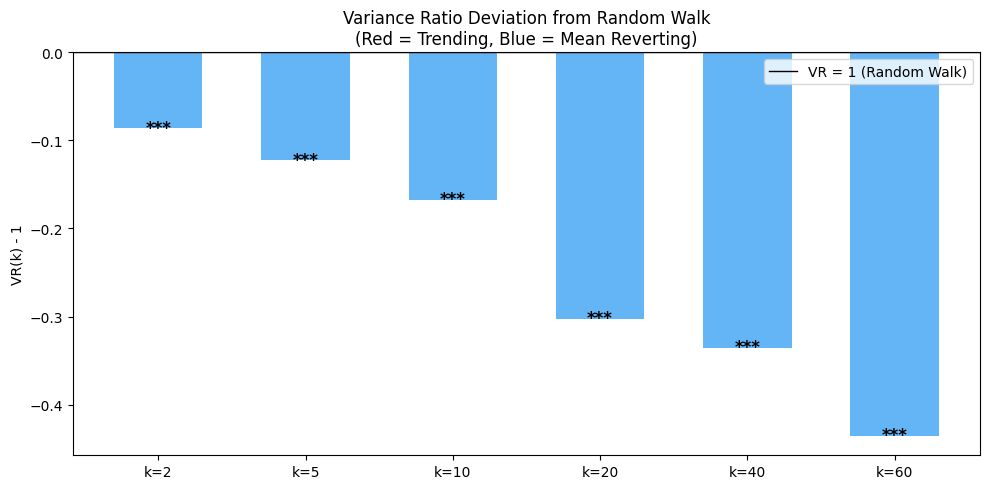

Average VR across lags: 0.7582
→ VR consistently < 1 → Returns exhibit MEAN REVERSION behavior


In [7]:
def variance_ratio_test(series, lags=None):
    """
    Lo-MacKinlay Variance Ratio test.
    
    Returns DataFrame with VR values and z-statistics for each lag.
    """
    if lags is None:
        lags = [2, 5, 10, 20, 40, 60]
    
    series = series.dropna().values
    n = len(series)
    
    # Variance of 1-period returns
    var_1 = np.var(series, ddof=1)
    
    results = []
    for k in lags:
        # k-period returns
        ret_k = series[k:] - series[:-k] if False else np.array([
            np.sum(series[i:i+k]) for i in range(n - k + 1)
        ])
        
        # Actually, for log returns, k-period return = sum of 1-period returns
        ret_k = pd.Series(series).rolling(k).sum().dropna().values
        
        var_k = np.var(ret_k, ddof=1)
        
        # Variance ratio
        vr = var_k / (k * var_1)
        
        # Z-statistic (asymptotic, under homoscedasticity)
        z_stat = (vr - 1) / np.sqrt(2 * (k - 1) / (n * k))
        
        # Two-sided p-value
        from scipy import stats
        p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))
        
        results.append({
            'Lag (k)': k,
            'VR(k)': vr,
            'z-stat': z_stat,
            'p-value': p_value,
            'Signal': 'Trend ↑' if vr > 1 else 'Revert ↓' if vr < 1 else 'Random'
        })
    
    return pd.DataFrame(results)

# Run Variance Ratio Test
vr_results = variance_ratio_test(log_returns)

print("=" * 70)
print("VARIANCE RATIO TEST (H0: VR = 1, Random Walk)")
print("=" * 70)
print(vr_results.to_string(index=False))
print()

# Plot VR across lags
fig, ax = plt.subplots(figsize=(10, 5))

lags = vr_results['Lag (k)']
vr_vals = vr_results['VR(k)']
p_vals = vr_results['p-value']

colors = ['#FF5722' if vr > 1 else '#2196F3' for vr in vr_vals]
bars = ax.bar(range(len(lags)), vr_vals - 1, color=colors, alpha=0.7, width=0.6)

ax.axhline(0, color='black', linewidth=1, linestyle='-')  # VR = 1 line
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([f'k={k}' for k in lags])
ax.set_ylabel('VR(k) - 1')
ax.set_title('Variance Ratio Deviation from Random Walk\n'
             '(Red = Trending, Blue = Mean Reverting)')

# Add significance markers
for i, (vr, p) in enumerate(zip(vr_vals, p_vals)):
    marker = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    ax.text(i, vr - 1 + 0.005 * np.sign(vr - 1), marker, 
            ha='center', fontsize=12, fontweight='bold')

ax.legend(['VR = 1 (Random Walk)'], loc='upper right')
plt.tight_layout()
plt.show()

# Summary
avg_vr = vr_vals.mean()
print(f"Average VR across lags: {avg_vr:.4f}")
if avg_vr > 1.05:
    print("→ VR consistently > 1 → Returns exhibit MOMENTUM / TRENDING behavior")
elif avg_vr < 0.95:
    print("→ VR consistently < 1 → Returns exhibit MEAN REVERSION behavior")
else:
    print("→ VR ≈ 1 → Returns are close to a random walk")

## 5. Half-Life of Mean Reversion

If the stock **does** mean-revert, how fast does it revert? We estimate the **half-life** by fitting an Ornstein-Uhlenbeck (OU) process:

$$\Delta y_t = \theta \cdot (y_{t-1} - \mu) + \epsilon_t$$

The half-life is: $\tau_{1/2} = -\frac{\ln(2)}{\ln(1 + \theta)}$

- **Short half-life (< 20 days)** → Fast mean reversion → Bollinger Bands, RSI strategies
- **Long half-life (> 60 days)** → Slow reversion → Not practical for short-term trading
- **Infinite / negative** → No mean reversion → Use trend following instead

SMA(20) spread → θ = -0.113917, Half-life = 5.7 days
SMA(50) spread → θ = -0.048986, Half-life = 13.8 days
SMA(100) spread → θ = -0.029407, Half-life = 23.2 days

HALF-LIFE ANALYSIS
Log Price half-life:   211.0 days (θ = -0.003280)
  OLS R² = 0.001805



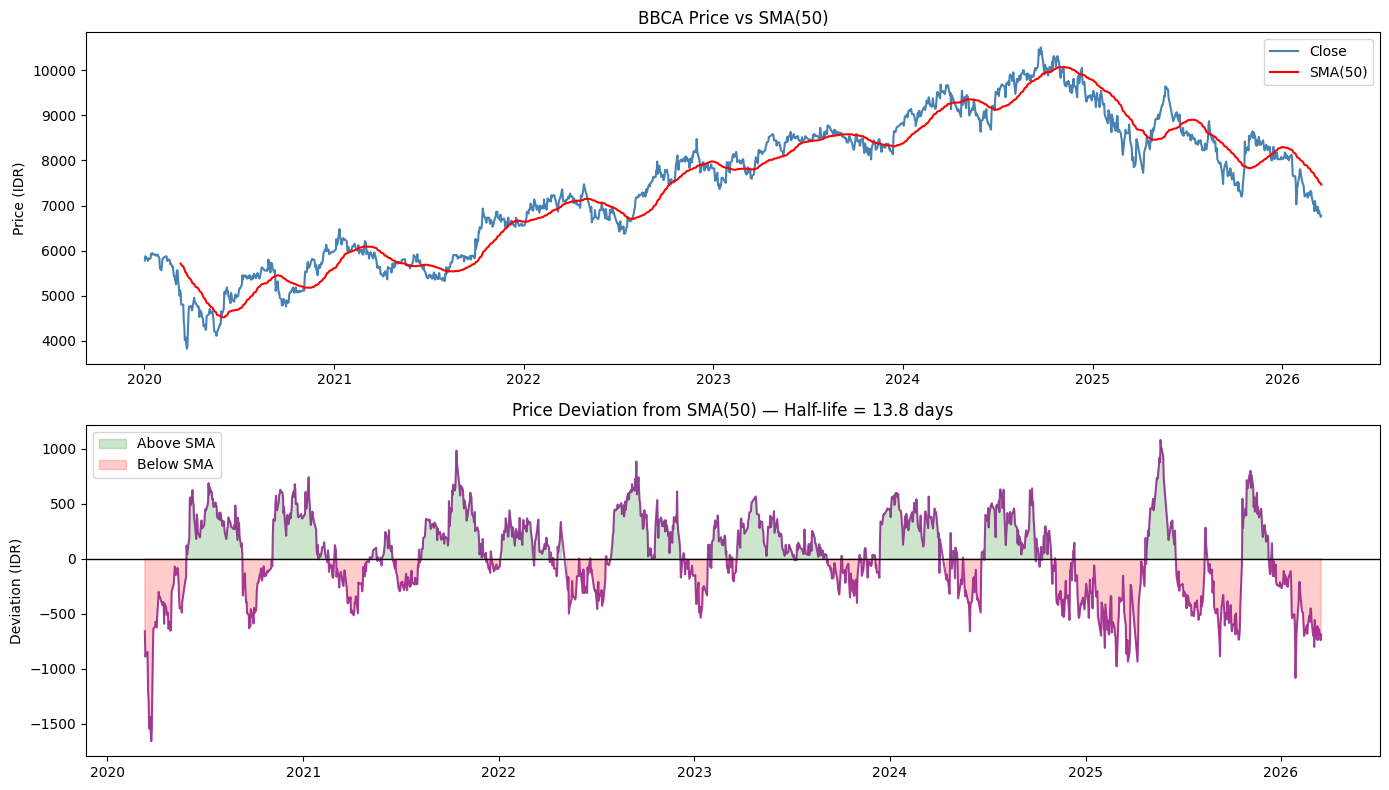


INTERPRETATION:
→ Half-life = 13.8 days → FAST mean reversion
  ✅ Bollinger Band / RSI mean reversion strategies viable


In [8]:
def compute_half_life(series):
    """
    Compute the half-life of mean reversion using OLS regression.
    
    Fits: Δy_t = θ * y_{t-1} + intercept + ε
    Half-life = -ln(2) / ln(1 + θ)
    """
    series = series.dropna()
    y_lag = series.shift(1).dropna()
    dy = series.diff().dropna()
    
    # Align
    y_lag = y_lag.iloc[1:]
    dy = dy.iloc[1:]
    
    # OLS regression: Δy = θ * y_{t-1} + c
    X = add_constant(y_lag)
    model = OLS(dy, X).fit()
    
    theta = model.params.iloc[1]
    
    if theta >= 0:
        half_life = np.inf  # No mean reversion
    else:
        half_life = -np.log(2) / np.log(1 + theta)
    
    return half_life, theta, model

# --- Test on log prices (for price-level mean reversion) ---
log_price = np.log(data['Close'])
hl_price, theta_price, model_price = compute_half_life(log_price)

# --- Test on price deviations from SMA (for spread mean reversion) ---
for sma_window in [20, 50, 100]:
    spread = data['Close'] - data['Close'].rolling(sma_window).mean()
    spread = spread.dropna()
    hl_spread, theta_spread, _ = compute_half_life(spread)
    print(f"SMA({sma_window}) spread → θ = {theta_spread:.6f}, Half-life = {hl_spread:.1f} days")

print()
print("=" * 60)
print("HALF-LIFE ANALYSIS")
print("=" * 60)
print(f"Log Price half-life:   {hl_price:.1f} days (θ = {theta_price:.6f})")
print(f"  OLS R² = {model_price.rsquared:.6f}")
print()

# Visual: deviation from SMA and how fast it reverts
sma_50 = data['Close'].rolling(50).mean()
spread_50 = data['Close'] - sma_50

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Price with SMA
axes[0].plot(data.index, data['Close'], label='Close', color='steelblue')
axes[0].plot(data.index, sma_50, label='SMA(50)', color='red', linewidth=1.5)
axes[0].set_title('BBCA Price vs SMA(50)')
axes[0].legend()
axes[0].set_ylabel('Price (IDR)')

# Spread (deviation from SMA)
axes[1].plot(data.index, spread_50, color='purple', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].fill_between(data.index, spread_50, 0, 
                      where=spread_50 > 0, color='green', alpha=0.2, label='Above SMA')
axes[1].fill_between(data.index, spread_50, 0, 
                      where=spread_50 < 0, color='red', alpha=0.2, label='Below SMA')

hl_50, _, _ = compute_half_life(spread_50.dropna())
axes[1].set_title(f'Price Deviation from SMA(50) — Half-life = {hl_50:.1f} days')
axes[1].set_ylabel('Deviation (IDR)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Interpretation
print("\nINTERPRETATION:")
if hl_50 < 20:
    print(f"→ Half-life = {hl_50:.1f} days → FAST mean reversion")
    print("  ✅ Bollinger Band / RSI mean reversion strategies viable")
elif hl_50 < 60:
    print(f"→ Half-life = {hl_50:.1f} days → MODERATE mean reversion")
    print("  ⚠️  Mean reversion possible but with longer holding periods")
else:
    print(f"→ Half-life = {hl_50:.1f} days → SLOW/NO mean reversion")
    print("  ❌ Mean reversion on price-SMA spread is impractical")

## 6. Rolling Regime Analysis

Markets **shift between regimes** — a stock can be trending for months, then mean-reverting. A single global test misses this. We compute rolling Hurst exponents and rolling Variance Ratios to see **when** the stock trends vs. reverts.

Computing rolling Hurst exponent (this may take a moment)...
Computing rolling Variance Ratio...


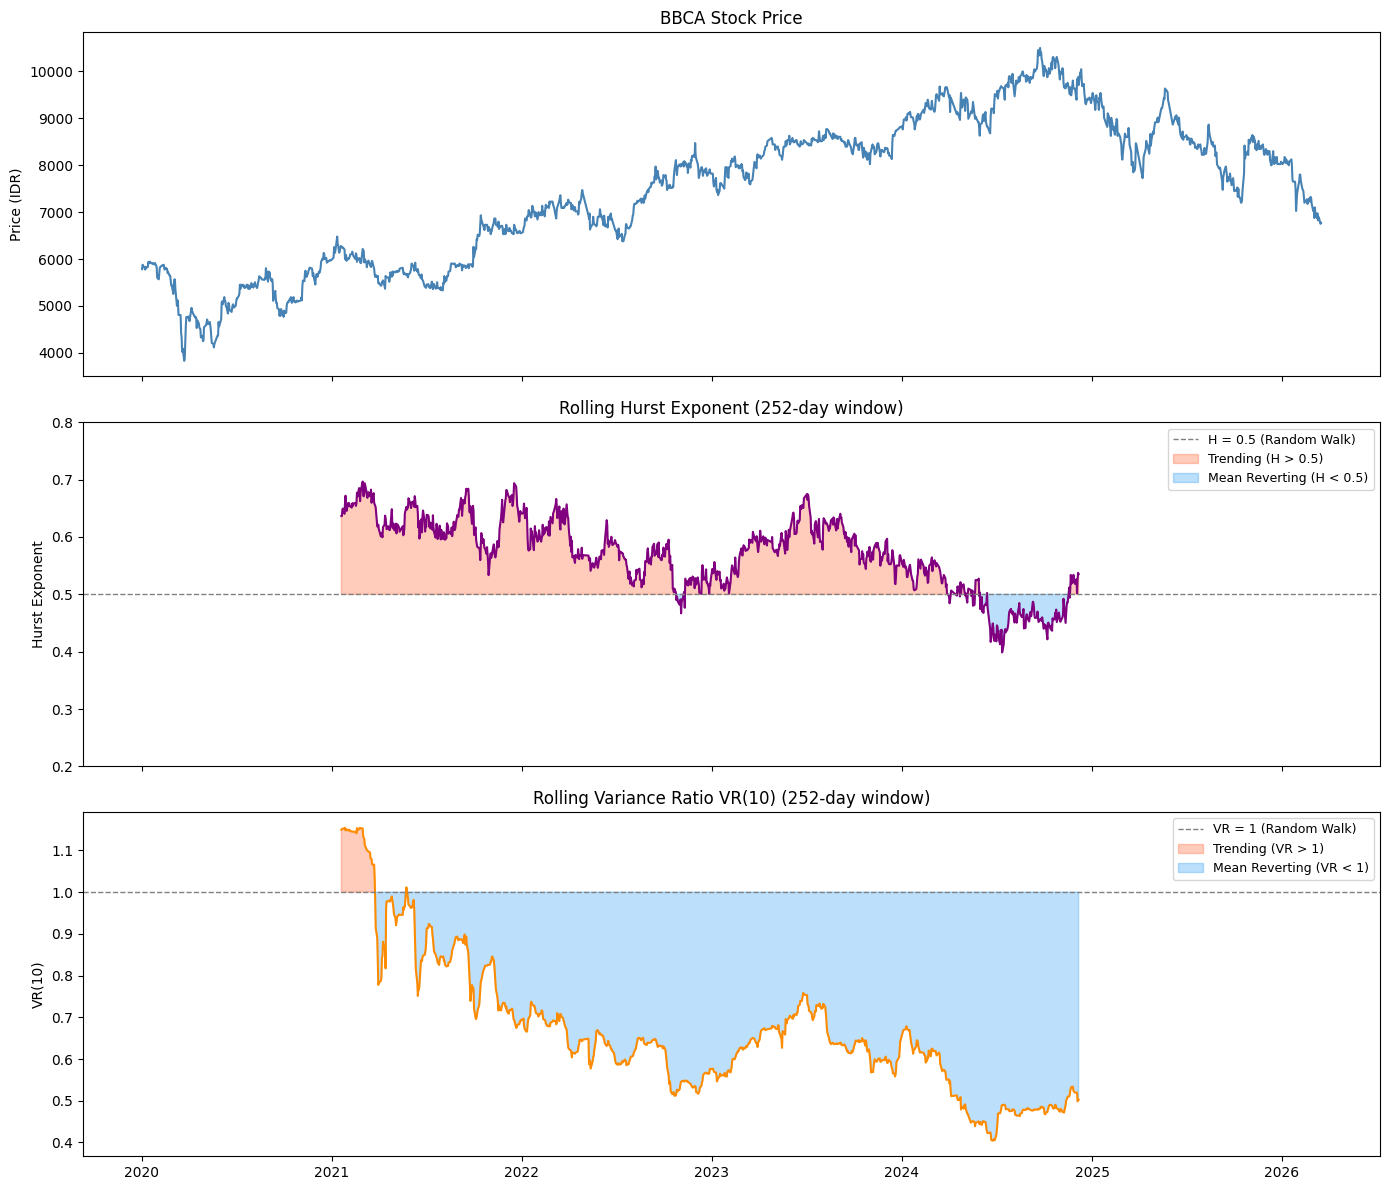

REGIME BREAKDOWN (based on rolling Hurst)
Trending periods (H > 0.5):       85.0%
Mean-reverting periods (H < 0.5):  15.0%
Current Hurst:                     0.5351

→ Stock spends MOST of its time in trending regimes
  ✅ Trend Following is the PRIMARY strategy


In [9]:
def rolling_hurst(series, window=252):
    """Compute rolling Hurst exponent over a sliding window."""
    result = pd.Series(index=series.index, dtype=float)
    values = series.values
    
    for i in range(window, len(values)):
        window_data = values[i - window:i]
        try:
            h, _, _ = hurst_exponent(pd.Series(window_data), min_window=10, max_window=window // 4)
            result.iloc[i] = h
        except:
            result.iloc[i] = np.nan
    
    return result

def rolling_variance_ratio(series, window=252, k=10):
    """Compute rolling VR(k) over a sliding window."""
    result = pd.Series(index=series.index, dtype=float)
    values = series.values
    
    for i in range(window, len(values)):
        window_data = values[i - window:i]
        var_1 = np.var(window_data, ddof=1)
        
        ret_k = pd.Series(window_data).rolling(k).sum().dropna().values
        var_k = np.var(ret_k, ddof=1)
        
        if var_1 > 0:
            result.iloc[i] = var_k / (k * var_1)
    
    return result

# Compute rolling metrics (1-year window)
print("Computing rolling Hurst exponent (this may take a moment)...")
roll_hurst = rolling_hurst(log_returns, window=252)

print("Computing rolling Variance Ratio...")
roll_vr = rolling_variance_ratio(log_returns, window=252, k=10)

# Plot
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Price
axes[0].plot(data.index, data['Close'], color='steelblue')
axes[0].set_ylabel('Price (IDR)')
axes[0].set_title('BBCA Stock Price')

# Rolling Hurst
axes[1].plot(roll_hurst.index, roll_hurst, color='purple', linewidth=1.5)
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='H = 0.5 (Random Walk)')
axes[1].fill_between(roll_hurst.index, roll_hurst, 0.5,
                      where=roll_hurst > 0.5, color='#FF5722', alpha=0.3, label='Trending (H > 0.5)')
axes[1].fill_between(roll_hurst.index, roll_hurst, 0.5,
                      where=roll_hurst < 0.5, color='#2196F3', alpha=0.3, label='Mean Reverting (H < 0.5)')
axes[1].set_ylabel('Hurst Exponent')
axes[1].set_title('Rolling Hurst Exponent (252-day window)')
axes[1].set_ylim(0.2, 0.8)
axes[1].legend(loc='upper right', fontsize=9)

# Rolling VR
axes[2].plot(roll_vr.index, roll_vr, color='darkorange', linewidth=1.5)
axes[2].axhline(1.0, color='gray', linestyle='--', linewidth=1, label='VR = 1 (Random Walk)')
axes[2].fill_between(roll_vr.index, roll_vr, 1.0,
                      where=roll_vr > 1, color='#FF5722', alpha=0.3, label='Trending (VR > 1)')
axes[2].fill_between(roll_vr.index, roll_vr, 1.0,
                      where=roll_vr < 1, color='#2196F3', alpha=0.3, label='Mean Reverting (VR < 1)')
axes[2].set_ylabel('VR(10)')
axes[2].set_title('Rolling Variance Ratio VR(10) (252-day window)')
axes[2].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Regime statistics
valid_hurst = roll_hurst.dropna()
pct_trending = (valid_hurst > 0.5).sum() / len(valid_hurst) * 100
pct_reverting = (valid_hurst < 0.5).sum() / len(valid_hurst) * 100

print("=" * 60)
print("REGIME BREAKDOWN (based on rolling Hurst)")
print("=" * 60)
print(f"Trending periods (H > 0.5):       {pct_trending:.1f}%")
print(f"Mean-reverting periods (H < 0.5):  {pct_reverting:.1f}%")
print(f"Current Hurst:                     {valid_hurst.iloc[-1]:.4f}")
print()
if pct_trending > 60:
    print("→ Stock spends MOST of its time in trending regimes")
    print("  ✅ Trend Following is the PRIMARY strategy")
elif pct_reverting > 60:
    print("→ Stock spends MOST of its time in mean-reverting regimes")
    print("  ✅ Mean Reversion is the PRIMARY strategy")
else:
    print("→ Stock alternates between regimes fairly equally")
    print("  ✅ Consider a REGIME-SWITCHING strategy that adapts")

## 7. Strategy Selection Summary

Combine all the evidence from the tests above into a single scorecard to determine the optimal strategy.

In [10]:
# ===================================================================
# STRATEGY SELECTION SCORECARD
# ===================================================================
# Collect evidence from all tests

evidence = []

# 1. Autocorrelation
avg_acf_short = np.mean(acf_values[1:6])
if avg_acf_short > 0.03:
    evidence.append(('Autocorrelation (lag 1-5)', 'Trend Following', f'Avg ACF = {avg_acf_short:+.4f}'))
elif avg_acf_short < -0.03:
    evidence.append(('Autocorrelation (lag 1-5)', 'Mean Reversion', f'Avg ACF = {avg_acf_short:+.4f}'))
else:
    evidence.append(('Autocorrelation (lag 1-5)', 'Neutral', f'Avg ACF = {avg_acf_short:+.4f}'))

# 2. Ljung-Box
lb_significant = len(lb_test[lb_test['lb_pvalue'] < 0.05]) > 0
evidence.append(('Ljung-Box Test', 
                  'Predictable' if lb_significant else 'Random Walk',
                  f'Significant at 5%: {lb_significant}'))

# 3. Hurst Exponent
if H > 0.55:
    evidence.append(('Hurst Exponent', 'Trend Following', f'H = {H:.4f}'))
elif H < 0.45:
    evidence.append(('Hurst Exponent', 'Mean Reversion', f'H = {H:.4f}'))
else:
    evidence.append(('Hurst Exponent', 'Neutral', f'H = {H:.4f}'))

# 4. ADF on prices
if adf_price['Stationary']:
    evidence.append(('ADF (Price)', 'Mean Reversion', f'p = {adf_price["p-value"]:.4f}'))
else:
    evidence.append(('ADF (Price)', 'Non-Stationary (typical)', f'p = {adf_price["p-value"]:.4f}'))

# 5. Variance Ratio
avg_vr = vr_results['VR(k)'].mean()
if avg_vr > 1.05:
    evidence.append(('Variance Ratio (avg)', 'Trend Following', f'Avg VR = {avg_vr:.4f}'))
elif avg_vr < 0.95:
    evidence.append(('Variance Ratio (avg)', 'Mean Reversion', f'Avg VR = {avg_vr:.4f}'))
else:
    evidence.append(('Variance Ratio (avg)', 'Neutral', f'Avg VR = {avg_vr:.4f}'))

# 6. Half-life (SMA50 spread)
if hl_50 < 20:
    evidence.append(('Half-Life (SMA50)', 'Mean Reversion', f'{hl_50:.1f} days'))
elif hl_50 < 60:
    evidence.append(('Half-Life (SMA50)', 'Weak Mean Reversion', f'{hl_50:.1f} days'))
else:
    evidence.append(('Half-Life (SMA50)', 'No Mean Reversion', f'{hl_50:.1f} days'))

# 7. Rolling regime
valid_hurst = roll_hurst.dropna()
pct_trending = (valid_hurst > 0.5).sum() / len(valid_hurst) * 100
if pct_trending > 60:
    evidence.append(('Rolling Regime', 'Trend Following', f'{pct_trending:.1f}% trending'))
elif pct_trending < 40:
    evidence.append(('Rolling Regime', 'Mean Reversion', f'{100-pct_trending:.1f}% reverting'))
else:
    evidence.append(('Rolling Regime', 'Mixed', f'{pct_trending:.1f}% trending'))

# Build scorecard
scorecard = pd.DataFrame(evidence, columns=['Test', 'Verdict', 'Value'])

# Count votes
trend_votes = sum(1 for _, v, _ in evidence if 'Trend' in v)
revert_votes = sum(1 for _, v, _ in evidence if 'Reversion' in v or 'Revert' in v)
neutral_votes = len(evidence) - trend_votes - revert_votes

print("=" * 70)
print("📊 STRATEGY SELECTION SCORECARD — BBCA.JK")
print("=" * 70)
print()
print(scorecard.to_string(index=False))
print()
print("-" * 70)
print(f"  🔴 Trend Following votes:  {trend_votes}")
print(f"  🔵 Mean Reversion votes:   {revert_votes}")
print(f"  ⚪ Neutral / Other:        {neutral_votes}")
print("-" * 70)
print()

# Final recommendation
if trend_votes > revert_votes and trend_votes >= 3:
    print("🏆 RECOMMENDATION: TREND FOLLOWING")
    print()
    print("  Suggested strategies:")
    print("  1. EMA Crossover (short/long EMA)")
    print("  2. Breakout (Donchian Channel / ATR-based)")
    print("  3. MACD Signal Line Crossover")
    print("  4. Momentum (ROC / RSI trend)")
elif revert_votes > trend_votes and revert_votes >= 3:
    print("🏆 RECOMMENDATION: MEAN REVERSION")
    print()
    print("  Suggested strategies:")
    print("  1. Bollinger Band Bounce (buy lower band, sell upper)")
    print("  2. RSI Oversold/Overbought")
    print("  3. Z-Score of Price-SMA Spread")
    print("  4. Pairs Trading (if multi-stock)")
else:
    print("🏆 RECOMMENDATION: REGIME-ADAPTIVE or HYBRID STRATEGY")
    print()
    print("  The evidence is mixed — the stock alternates between regimes.")
    print()
    print("  Suggested approaches:")
    print("  1. Regime-Switching: Use rolling Hurst to toggle between")
    print("     trend-following (H > 0.5) and mean-reversion (H < 0.5)")
    print("  2. Volatility-Based: Trend-follow in high-vol, mean-revert in low-vol")
    print("  3. ML Classification: Train a model to predict the regime,")
    print("     then apply the appropriate strategy")
    print("  4. Ensemble: Combine both strategy types with adaptive weighting")

📊 STRATEGY SELECTION SCORECARD — BBCA.JK

                     Test                  Verdict                   Value
Autocorrelation (lag 1-5)                  Neutral       Avg ACF = -0.0202
           Ljung-Box Test              Predictable Significant at 5%: True
           Hurst Exponent          Trend Following              H = 0.5566
              ADF (Price) Non-Stationary (typical)              p = 0.5647
     Variance Ratio (avg)           Mean Reversion         Avg VR = 0.7582
        Half-Life (SMA50)           Mean Reversion               13.8 days
           Rolling Regime          Trend Following          85.0% trending

----------------------------------------------------------------------
  🔴 Trend Following votes:  2
  🔵 Mean Reversion votes:   2
  ⚪ Neutral / Other:        3
----------------------------------------------------------------------

🏆 RECOMMENDATION: REGIME-ADAPTIVE or HYBRID STRATEGY

  The evidence is mixed — the stock alternates between regimes.

  Sug